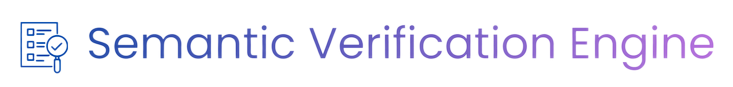

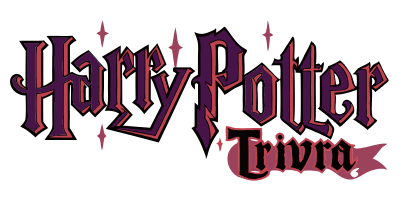

<div style="background-color: #f0e6f7; padding: 10px;">
    <h2 style="text-align:center; color:purple;">EDA, Feature Engineering, & Baseline Dataset v.0</h3>
</div>

# 1: Introduction

This work is part of a two-notebook series focused on preparing the Harry Potter trivia dataset for use in the Command-Line Interface (CLI) game. Across the series, the raw data is cleaned and standardized, its suitability for gameplay is evaluated, and features generated to support deeper analysis. The dataset is sourced from [saracandu/harry-potter-trivia-human](https://huggingface.co/datasets/saracandu/harry-potter-trivia-human/tree/main) on Hugging Face, downloaded on January 25, 2025 using the download_data.py script. The train and test splits were combined into a single CSV for processing.

### Scope of the notebook

Building from the initial cleaning and EDA from the [first notebook](../notebooks/01_cleaning_and_eda.ipynb), this analysis focuses on deeper feature engineering and addressing data quality issues. The key objectives are:

1. **Content Similarity analysis**: use cosine similarity to measure and analyze the semantic relationships *within* the questions, *within* the answers, and *between* question-answer pairs. 
2. **Advanced feature engineering**: refine the dataset by categorizing questions into distinct types (e.g., factual, explanatory), standardizing quantitative answers, and reclassifying ambiguous how questions. This step also addresses data quality issues like incomplete or out-of-scope questions.
3. **Develop a Data Ingestion Pipeline**: Create an automated pipeline to standardize the process of adding new questions. This will ensure data consistency, improve efficiency, and reduce manual errors.
4. **Create a Dataset Dashboard**: Build an automated "status map" to provide a snapshot of key dataset metrics. This dashboard will help monitor data quality and ensure a balanced distribution of question types and topics over time. 
5. **Establish a baseline dataset**: Finalize and process the dataset and create the basline dataset. This will be a benchmark for how the dataset evolves and grows over time.
6. **Perform quality assurance**: Develop and implement a quality assurance scheme to confirm the quality of the baseline dataset.
7. **Finalize and export the dataset for the game**: convert the baseline dataset into a csv file and export for the game.

# Table of Contents

1. [Introduction](#1-introduction)<br>
2. [Glossary of key terms](#2-glossary-of-key-terms)<br>
3. [Setup and imports](#3-setup-and-imports)<br>
4. [**Content Similarity Analysis**](#4-content-similarity-analysis)<br>
    4.1. [Question-Answer pariwise comparison](#41-question-answer-q-a-pairwise-comparison)<br>
    4.2. [Question-Question comparison](#42-question-question-q-q-comparison)<br>
    4.3. [Answer-Answer comparison](#43-answer-answer-a-a-comparison)<br>
5. [**Feature engineering for downstream tasks**](#5-feature-engineering-for-downstream-tasks)<br>
    5.1. [Length metrics](#51-length-metricss)<br>
    5.2. [Classify questons into types](#52-classify-questions-into-types)<br>
    5.3. [Engineering answer type for smarter validation](#53--engineering-answer_type-for-smarter-validation)<br>
6. [**Preliminary status map of the dataset**](#6-preliminary-status-map-of-the-dataset)
7. [**Data Injestion pipeline**](#7-data-ingestion-pipeline)<br>
    7.1. [Standardize requirements for new addtions to the trivia dataset](#71-standardized-requirements-for-new-additions-to-the-trivia-dataset)<br>
    7.2. [Data ingestion pipeline processing steps](#72-data-ingestion-pipeline-process-steps)<br>
8. [**Establishing the baseline dataset**](#8-establishing-the-baseline-dataset)<br>
    8.1. [Dataset status dashboard and results analysis](#81-dataset-status-dashboard-and-results-analysis)<br>
    8.2. [Data schema (data dictionary)](#82-data-schema-data-dictionary)<br>
9. [**Data quality assurance and finalization**](#9-data-quality-assurance-and-finalization)<br>
    9.1. [Quality assurance scheme](#91-quality-assurance-scheme)<br>
    9.2. [Current quality confirmation](#92-current-quality-confirmation)<br>
10. [Summary and key findings](#10-summary-and-key-findings)<br>
    10.1. [Gaps and limitations](#101--gaps-and-limitations)<br>
    10.2. [Next steps](#102-nexts-stepss)<br>
11. [References](#11-references)<br>

# 2: Glossary of key terms

To ensure clarity and consistency, the following terms are defined within the context of this analysis:

|Term | Abbreviation | Description|
|-|-|-|
|Question| Q | A trivia question in the dataset|
|Answer|A| An answer to a trivia question in the dataset|
|Factual Recall (Question) | FR | Question seeking specific objective info (name, date, place, etc.). Identified by keywords such as 'What', 'Who', etc. |
| Explanatory|EX| Question seeking explanation, opinion, or procedure, often identified by keywords like 'Why' or 'How'.|
| Multiple-Choice Question| MCQ| A question that provides options for answers to select from|
| Yes / No (Question)| YN| Questions that elicit set responses such as yes, no, true, false|
| Question Type| QT | Classification assigned (e.g., Factual-Recall, Open-Ended) based primarily on keywords/phrasing, answer type |
| Question Keyword | QK | Lemmatized token from question text used for analysis/filtering (standard stopwords removed, interrogatives kept). |
| MVP of game| CLI-MVP | The first phase prototype of the Harry Potter Trivia game (Command Line Interface - Minimum Viable Product) |
| Quality Assurance | QA | methods and schemes developed to assess the quality of the dataset|  

# 3: Setup and imports

First, let's import the necessary external packages as well as internal project environment configuration and custom helper and utility methods from project modules.

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import json
import sys
sys.path.append('..')
# --- Core Libraries ---
import pandas as pd
import matplotlib.pyplot as plt
# --- Project-Specific Imports ---
import ds_utils.notebook_config as nb_cfg
from ds_utils import eda_scripts as eda
from ds_utils import ds_constants as const
# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


In [2]:
# --- Notebook-Specific Imports ---
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from word2number import w2n
from pprint import pprint
import networkx as nx
from IPython.core.display import Markdown
from IPython.display import display
import textstat
# custom tokenizer from project ds utils
from ds_utils.text_processing import tokenize_text

We also need to import the dataframe output from the [previous notebook](../notebooks/01_cleaning_and_eda.ipynb) so that we can continue with our analysis. The dataframe is stored as a paraquet file to ensure that the dataframe data types remain intact. 

In [3]:
# import dataset (with notebook 1 processing) - EDA and Curation
file_path = nb_cfg.INTERMEDIATE_DATA_DIR/ "dataframe_nb1_output_v0.parquet"
df_loaded_from_checkpoint = pd.read_parquet(file_path)
# set 'original_question' as index
# df_loaded_from_checkpoint = df_loaded_from_checkpoint.set_index(df_loaded_from_checkpoint.columns[0])
df_loaded_from_checkpoint.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword
0,0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school,...","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school,...","[what, be]",what
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[10th, century]","[when, be, hogwarts, found, 10th, century]","[when, be]",when
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]","[what, be]",what
3,3,You wouldn't know anything about this. Name a ...,Using polish,"[know, anything, name, method, make, broom, go...","[use, polish]","[know, anything, name, method, make, broom, go...",[name],name
4,4,Harry first took the Knight Bus in The Prisone...,14 sickles.,"[harry, first, take, knight, bus, prisoner, az...","[14, sickle]","[harry, first, take, knight, bus, prisoner, az...","[how, do]",how


Now, to be safe we can create a copy of the dataframe going forward.

In [4]:
# df to be used going ahead
df_for_analysis= df_loaded_from_checkpoint.copy()
# Sanity check
df_for_analysis.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword
0,0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school,...","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school,...","[what, be]",what
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[10th, century]","[when, be, hogwarts, found, 10th, century]","[when, be]",when
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]","[what, be]",what
3,3,You wouldn't know anything about this. Name a ...,Using polish,"[know, anything, name, method, make, broom, go...","[use, polish]","[know, anything, name, method, make, broom, go...",[name],name
4,4,Harry first took the Knight Bus in The Prisone...,14 sickles.,"[harry, first, take, knight, bus, prisoner, az...","[14, sickle]","[harry, first, take, knight, bus, prisoner, az...","[how, do]",how


As a reminder of where we left off:
1. **New features were introduced** This included lemmatized tokens with stop words removed for the question, answer, and both combined. Interrogative keywords for record were isolated to assess and determine the nature of the questions. And a main interrogative keyword.
2. The questions could be binned according  
2. We found that the `main_keyword` was a good indicator of the type of question  to use to classiffy questions into main types: Factual Recall (FR), Explanatory ()

<a href="#table-of-contents" 
style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">
Back to TOC
</a>

## 4: Content similarity analysis

We got a strong understanding through the preliminary EDA based on numerical and descriptive techniques. Cosine similarity provides another angle for understanding the dataset by measuring the semantic relatedness of the text. This analysis will focus on four distinct comparisons.

#### Methodology
To perform these comparisons, a common vocabulary will be built from the pre-processed `question tokens` and `answer tokens` columns. A single *TF-IDF vectorizer* will be used to ensure that all similarity scores are directly comparable, as they will be based on the same features and IDF weights. The analysis will include n-grams (from 1 to 3 words) to capture common and specific phrases like "harry potter" or "defense against dark arts."

#### Analysis plan

1. **Question-Answer pairwise comparison**:<br>
This will measure the vocabulary overlap between each question and its direct answer. The similarity is expected to be low, as the short, factual answers are unlikely to repeat words from the questions. High-scoring outliers could be interesting, potentially flagging questions that are too simple or contain errors.

2. **Question-Question comparison**:<br>
Comparing each question to all other questions will help quantify the dataset's thematic diversity. High similarity scores will reveal clusters of questions focused on specific topics (e.g., characters, spells, locations) and can also serve as a check for near-duplicate questions missed during initial cleaning. This will also inform the future Named Entity Recognition (NER) work by identifying the primary custom entities to create.

3. **Answer-Answer comparison**:<br>
Similarly, this comparison can reveal thematic clusters based on the answers themselves. This can provide a more direct view of the most common subjects and the diversity of factual knowledge contained in the dataset.

4. **Question-Answer matrix comparison**:<br>
This comprehensive comparison would analyze the relationship between every question and every answer, not just paired ones. While it could reveal deeper thematic connections, this more intensive analysis can be deferred to a later phase depending on the outcomes of the first three steps. 


#### Setup a common vectorizer
This would use keywords from both questions and answers. We can use the `combined_unique_tokens` column since it already has normalized, processed tokens from both. The column will have to be converted from a list of tokens to a string before vectorizing.

In [5]:
# Key variables
column_name = 'combined_unique_tokens'
ngram_range = (1,3)
stop_words = [] # in case there are additional words.
# Default min_df and max_df

# 1. combine the combined unique keyword column into a string.
df_tfidf_cs = df_for_analysis.copy()
df_tfidf_cs['all_keywords_str'] = df_tfidf_cs[column_name].apply(lambda token_list: ' '.join(token_list))

df_tfidf_cs.head()


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword,all_keywords_str
0,0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school,...","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school,...","[what, be]",what,what be three european wizarding school partic...
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[10th, century]","[when, be, hogwarts, found, 10th, century]","[when, be]",when,when be hogwarts found 10th century
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]","[what, be]",what,what be wronski feint pretend dive snitch
3,3,You wouldn't know anything about this. Name a ...,Using polish,"[know, anything, name, method, make, broom, go...","[use, polish]","[know, anything, name, method, make, broom, go...",[name],name,know anything name method make broom go faster...
4,4,Harry first took the Knight Bus in The Prisone...,14 sickles.,"[harry, first, take, knight, bus, prisoner, az...","[14, sickle]","[harry, first, take, knight, bus, prisoner, az...","[how, do]",how,harry first take knight bus prisoner azkaban h...


The new `all_keywords_str` string column can now be used to define the TF-IDF vectorizer.

In [6]:
# 2. Initialize the tf-idf vectorizer:
vectorizer = TfidfVectorizer(stop_words= stop_words, ngram_range= ngram_range)

# 3.Fit the vectorizer on the combined tokens
vectorizer.fit(df_tfidf_cs['all_keywords_str'])

TfidfVectorizer(ngram_range=(1, 3), stop_words=[])

To buid the vocabulary, we would need to use to look at the vocabulary of both the question and answer. So the `vectorizer` must be used to transform the `question tokens` and `answer tokens` columns together using a custom method in [eda_scripts](../src/ds_utils/eda_scripts.py).

In [7]:
# 4. Transform the question and answer tokens with the vectorizer to get their respective sparse matrices.
X_questions, Y_answers = eda.transform_for_similarity_check(df_tfidf_cs, vectorizer)

Now we can proceed with our similarity analysis.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 4.1: Question-Answer (Q-A) pairwise comparison
Now that we have the sparse matrices, we can go ahead and calculate the cosine similarity scores of each questions to its answer.

In [8]:
# 1. Create a full similarity matrix
full_qa_similarity_matrix = cosine_similarity(X_questions, Y_answers)
# 2. The pair-wise comparison of question and its answer = to the diagonal of the matrix
paired_qa_similarity = pd.Series(full_qa_similarity_matrix.diagonal(), index=df_tfidf_cs.index)
paired_qa_similarity.describe().round(3)

count    1084.000
mean        0.014
std         0.048
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         0.435
dtype: float64

In [9]:
# Filter the trivia dataframe where the cosine similarity score is not 0
df_nonzero_qa_similarity = df_for_analysis.loc[(paired_qa_similarity != 0)].copy()
# Append the cosine simiilarity score for analysis
df_nonzero_qa_similarity['cosine_score'] = paired_qa_similarity
 
# categorized the rows into similarity score bins based on describe / barchart results
bins = [0, 0.1, 0.2, 0.3, 0.5] 
labels = ['(0.0, 0.1]', '(0.1, 0.2]', '(0.2, 0.3]', '(0.3, 0.5]']
df_nonzero_qa_similarity['similarity_bin'] = pd.cut(df_nonzero_qa_similarity['cosine_score'],
                                                        bins=bins,
                                                        labels=labels,
                                                        right=True) # Includes the right edge

# df_nonzero_qa_similarity[['question', 'answer', 'question tokens', 'answer tokens']].head(5)
df_nonzero_qa_similarity.head()

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword,cosine_score,similarity_bin
22,22,What potion allows a witch or wizard to disgui...,Polyjuice Potion.,"[what, potion, allow, witch, wizard, disguise,...","[polyjuice, potion]","[what, potion, allow, witch, wizard, disguise,...",[what],what,0.044534,"(0.0, 0.1]"
48,48,Who becomes the Charms professor after Profess...,Filius Flitwick remains the Charms professor t...,"[who, become, charm, professor, flitwick]","[filius, flitwick, remain, charm, professor, t...","[who, become, charm, professor, flitwick, fili...",[who],who,0.284922,"(0.2, 0.3]"
88,88,What does the Ear-Shrivelling Curse cause?,Ears to wither,"[what, do, ear, shrivel, curse, cause]","[ear, wither]","[what, do, ear, shrivel, curse, cause, wither]","[what, do]",what,0.148403,"(0.1, 0.2]"
103,103,Did Muggles use ancient runes as well?,They did.,"[do, muggles, use, ancient, rune, well]",[do],"[do, muggles, use, ancient, rune, well]",[do],do,0.094702,"(0.0, 0.1]"
109,109,What is the primary school attended by Harry P...,Hogwarts School of Witchcraft and Wizardry,"[what, be, primary, school, attend, harry, pot...","[hogwarts, school, witchcraft, wizardry]","[what, be, primary, school, attend, harry, pot...","[what, be]",what,0.064548,"(0.0, 0.1]"


In [10]:
#  High-level counts
total_records = df_for_analysis.shape[0]
zero_qa_similarity = df_for_analysis.loc[paired_qa_similarity == 0]['question'].count()
print(f"* There are {zero_qa_similarity} ({(zero_qa_similarity/total_records)*100:.2f} %) question-answer pairs with a similarity score of 0.\n"
      f"* There are {df_nonzero_qa_similarity.shape[0]} question-answer pairs with a cosine similarity score greater than 0.")
# summary of counts for each bin
summary_df = df_nonzero_qa_similarity.groupby('similarity_bin', observed=False).agg(qa_pair_count=('question', 'count'))
summary_df['Percentage of non-zero similarity scores (%)']= ((summary_df['qa_pair_count']/summary_df['qa_pair_count'].sum())*100).round(1)
summary_df['Percentage of trivia df (%)'] = ((summary_df['qa_pair_count']/total_records)*100).round(2)

summary_df

* There are 967 (89.21 %) question-answer pairs with a similarity score of 0.
* There are 117 question-answer pairs with a cosine similarity score greater than 0.


,qa_pair_count,Percentage of non-zero similarity scores (%),Percentage of trivia df (%)
similarity_bin,,,
"(0.0, 0.1]",54,46.2,4.98
"(0.1, 0.2]",46,39.3,4.24
"(0.2, 0.3]",10,8.5,0.92
"(0.3, 0.5]",7,6.0,0.65


Majority of the question-answer pairs (89%) have cosine similarity score of 0. This means the majority of questions in the dataset share no meaningful vocabulary (after removing stop words) with their corresponding answers.  This makes sense since majority of the dataset is factual-recall. The answers are 1-3 words would be specific and not repeat the question (e.g., Q: "Who is the Minister for Magic?" A: "Cornelius Fudge").

For the remaining questions (11% of dataset), most (9% of dataset) have a very low similarity score (0< score <= 0.2), and a small fraction (~2%) have low-medium score between 0.2 and 0.5 - showing som overlap in vocabulary between the question and it's answer.  These higher-scoring pairs likely represent more descriptive questions where the answer naturally shares some contextual words with the question. 

Let's take a look at samples from the highest `similarity_score` bin (0.3< score <= 0.5):

In [11]:
# since the bins are categorical, can use query
columns = ['question','answer','question tokens', 'answer tokens','interrogative_keywords','main_keyword','cosine_score','similarity_bin']
df_nonzero_qa_similarity[df_nonzero_qa_similarity['similarity_bin']=='(0.3, 0.5]'][columns].sample(5, random_state=16)

,question,answer,question tokens,answer tokens,interrogative_keywords,main_keyword,cosine_score,similarity_bin
629,How is Bellatrix related to Tonks?,Tonks is Bellatrix's niece.,"[how, be, bellatrix, relate, tonks]","[tonks, be, bellatrix, niece]","[how, be]",how,0.435035,"(0.3, 0.5]"
749,"Who is NOT in Slytherin: Lavender Brown, Pansy...",Lavender Brown,"[who, be, slytherin, lavender, brown, pansy, p...","[lavender, brown]","[who, be]",who,0.307653,"(0.3, 0.5]"
489,Fill in the blank: Petrificus Totalus is the i...,Bind (Got this in the Petrificus Totalus lesson.),"[fill, blank, petrificus, totalus, be, incanta...","[bind, get, petrificus, totalus, lesson]",[be],be,0.341430,"(0.3, 0.5]"
651,Is it safe to drink water conjured by Aguamenti?,"Yes, it's safe to drink.","[be, safe, drink, water, conjure, aguamenti]","[yes, safe, drink]",[be],be,0.388192,"(0.3, 0.5]"
795,"Who is NOT in Gryffindor: Harry Potter, Ron We...",Draco Malfoy,"[who, be, gryffindor, harry, potter, ron, weas...","[draco, malfoy]","[who, be]",who,0.301205,"(0.3, 0.5]"


The question-answers within the highest bin are the non-factual types. This includes multiple-choice questions where the answer is one of the options listed in the prompt (Q.749 "Who is NOT in Slytherin: Lavender Brown, Pansy Parkinson, Blaise Zabini, or Gregory Goyle? Lavender Brown). The same is true for the Yes/No type questions (Q.489, Q.651) where the answer often repeats the verb from the query. In the case of open-ended questions, the overlap is to give context.

When we specifically look at the question-answer pair with the maximum similarity score, their score is so high because they share key nouns ('tonks', 'bellatrix') and 'be' in common.

In [12]:
max_cs_score = df_nonzero_qa_similarity.loc[df_nonzero_qa_similarity['cosine_score'].idxmax()]
max_cs_score

original_question_id                                             629
question                          How is Bellatrix related to Tonks?
answer                                   Tonks is Bellatrix's niece.
question tokens                  [how, be, bellatrix, relate, tonks]
answer tokens                          [tonks, be, bellatrix, niece]
combined_unique_tokens    [how, be, bellatrix, relate, tonks, niece]
interrogative_keywords                                     [how, be]
main_keyword                                                     how
cosine_score                                                0.435035
similarity_bin                                            (0.3, 0.5]
Name: 629, dtype: object

We can also plot the breakdown of each bin by the `interrogative_keywords` to identify any patterns. 

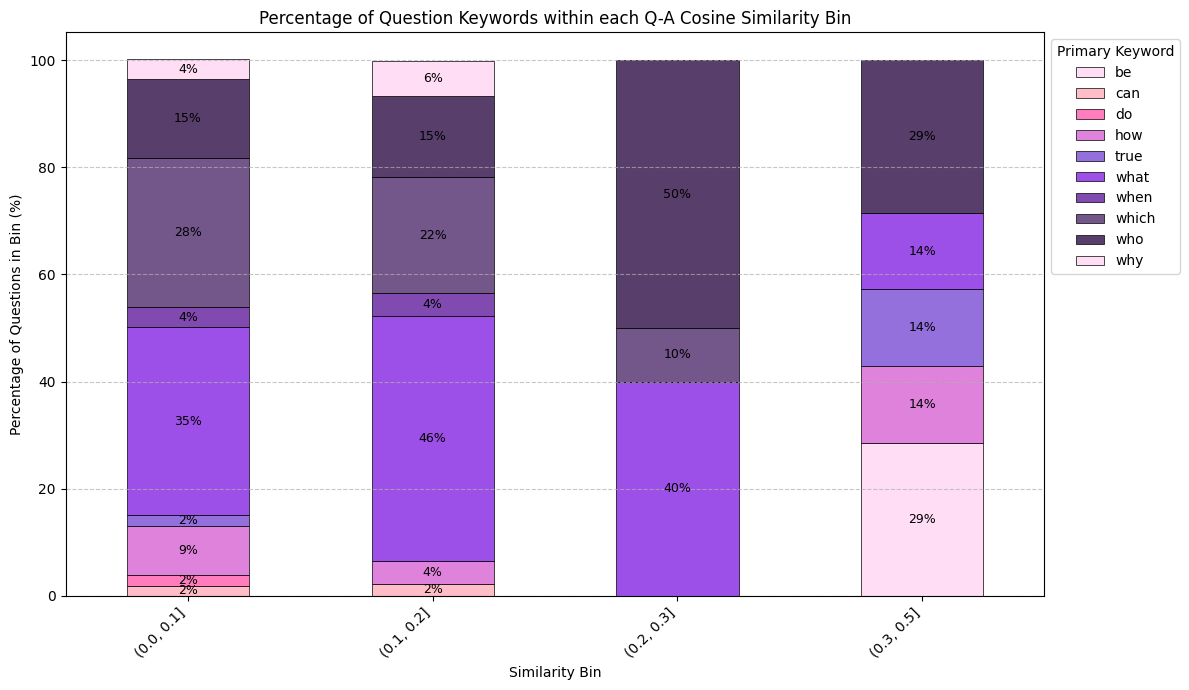

In [13]:
# Perform the groupby using the `main_keyword` column:
keyword_distribution_by_bin = df_nonzero_qa_similarity.groupby(
    ['similarity_bin', 'main_keyword'], 
    observed=True
).size().unstack(fill_value=0)

# Plot results
keyword_dist_by_bin_percent = keyword_distribution_by_bin.apply(lambda x: (x / x.sum() * 100), axis=1).round(1) 
# Color Palette (shades of purple)
purple_shades = [
    # --- Group 1: Pinks (for auxiliary verbs) ---
    '#FFDDF4',  # Lightest Pink
    "#FFB6C1E3",  # Light Pink
    "#FF69B4DE",  # Hot Pink
    # --- Transition Color ---
    "#DA70D6DE",  # Orchid (Pink-Purple)
    # --- Group 2: Purples (for interrogative verbs) ---
    '#9370DB',  # Medium Purple
    "#892BE2D3",  # Blue Violet
    "#6725A1D4",  # Purple
    "#4B2568C6",  # Bright Grape
    "#3A1B50D8",  # Indigo
]
num_keywords = len(keyword_dist_by_bin_percent.columns)
colors_to_use = purple_shades[:num_keywords] 

# Create the plot and get the Axes object
ax = keyword_dist_by_bin_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7), # Increased height slightly for labels
    color=colors_to_use, # Apply your custom color palette
    edgecolor='black',             # border color
    linewidth=0.5,                   # border width
    title="Percentage of Question Keywords within each Q-A Cosine Similarity Bin"
)
ax.set_ylabel("Percentage of Questions in Bin (%)")
ax.set_xlabel("Similarity Bin") # Added xlabel for clarity
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added y-axis grid for readability

# Add percentage labels for the stacks for each bin
for i, sim_bin_label in enumerate(keyword_dist_by_bin_percent.index):
    cumulative_height = 0
    # Iterate over each keyword (each segment in the stack for that bin)
    for keyword_col in keyword_dist_by_bin_percent.columns:
        percentage_value = keyword_dist_by_bin_percent.loc[sim_bin_label, keyword_col]

        # Only add label if the percentage is greater than a small threshold (e.g., 1%)
        # to avoid cluttering with tiny labels. Adjust threshold as needed.
        if percentage_value > 1: # You can adjust this threshold
            # Calculate the y position for the label (center of the segment)
            label_y_position = cumulative_height + (percentage_value / 2)
            ax.text(
                i,                             # x-coordinate (bar index)
                label_y_position,              # y-coordinate (center of segment)
                f"{percentage_value:.0f}%",    # Text label (integer percentage)
                ha='center',                   # Horizontal alignment
                va='center',                   # Vertical alignment
                color='black',                 # Label color (adjust if needed for contrast)
                fontsize=9,                    # Font size for labels
            )
        cumulative_height += percentage_value

ax.legend(title='Primary Keyword', bbox_to_anchor=(1, 1), loc='upper left')

fig = ax.get_figure()
plt.tight_layout()
plt.show()

We get a fuller picture of the keyword distribution with the chart that confirms the observations made from sampling the highest similarity score bin. The chart shows that as the Q-A similarity score increases, the distribution of question keywords within the bin changes as well:
- **Low Similarity Bins (0.0 to 0.3)**: These bins are majority factual-recall keywords such as  `what`, `which`, `when`, and `who`. This makes sense, as a question like "What is the name of Harry's owl?" has very little word overlap with its answer, "Hedwig."
- **High Similarity Bin (0.3 to 0.5)**: This bin on the other hand is composed of yes/no keywords, `be` (43%), `can` (14%), and `do` (14%). This is because the answers to these questions often repeat the verb from the question (e.g., Q: "Can it be used?" A: "Yes, it can."), resulting in high word overlap and a high similarity score.

So, a low similarity score can be an indicator of a factual-recall question, while a high similarity score is a strong indicator of a yes/no question.    

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

### 4.2: Question-Question (Q-Q) comparison
The similarity between questions will give us a better sense of the thematic diversity of the dataset and identify and handle the near-duplicates. We can get a high-level outlook through the distribution of the similairty scores between the questions.

In [14]:
# 1. Create a full similarity matrix
qq_similarity_matrix = cosine_similarity(X_questions, X_questions)
# Print summary descriptive statistics for the similarity matrix:
eda.print_similarity_matrix_stats(qq_similarity_matrix)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (1084, 1084)
* Number of unique pairwise scores (off-diagonal): 586986
* Percentage of non-zero scores: 58.14%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    586986.0000
mean          0.0076
std           0.0196
min           0.0000
25%           0.0000
50%           0.0036
65%           0.0053
66%           0.0054
75%           0.0073
90%           0.0192
95%           0.0310
99%           0.0737
max           1.0000
dtype: float64
--------------------------------------------------


The descriptive statistics show that the similarity scores between question pairs are overwhelmingly low. The mean similarity is just 0.0076, and the median is even lower at 0.0036. More importantly, 99% of all question pairs have a similarity score of 0.074 or less. This further confirms that the **dataset is made up of highly diverse, factual-recall questions with very little semantic overlap**. 

As this section is quite lengthy, quick links are provided below to help with navigation.

<div style="text-align: left;">

<a href="#421-identifying-near-duplicates-with-q-q-similarity" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">4.2.1. ID near duplicates</a>
<a href="#422-approach" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">4.2.2. Approach</a>
<a href="#423-initial-quality-filtering" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">4.2.3. Initial quality filtering</a>
<a href="#424-duplicate-detection" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">4.2.4. Duplicate detection</a>
<a href="#425-golden-record-selection" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">4.2.5. Golden record selection</a>
<a href="#426-validation-of-the-tagging-against-v0" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">4.2.6. Validation</a>
<a href="#427-remove-the-duplicates" style="display:inline-block; padding:8px 12px; margin:4px; background-color:#9e8ccf; color:white; text-align:center; text-decoration:none; border-radius:4px;">4.2.7. Remove duplicates</a>

#### 4.2.1: Identifying Near-Duplicates with Q-Q Similarity

Any score above this 99th percentile is a significant outlier and a strong candidate for being a near-duplicate. Near-duplicates could also be found at lower percentiles but these are likely mixed in with similar worded but different questions. A nuanced approach is required to evaluate the near-duplicates. The deduplication is necessary because the simple deduplication in the data preparation phase missed matches because of minor differences in punctuation, capitalization, or wording (e.g., 'Gamekeeper' vs. 'gamekeeper'). These differences disappear when the text is normalized by the custom tokenizer, revealing the true similarity.

#### 4.2.2: Approach

While a simple pairwise comparison can find some of these matches, it doesn't capture complete sets of duplicates (e.g., if A matches B, and B matches C, all three should be in one group). To address this, a **graph-based approach** is used. By treating questions as nodes and similarity scores as edges, we can consolidate all pairwise findings into distinct, complete groups. 

>#### Methodology update: from v0 iteration to v.0.1 automation
>
> The main reason for the updated workflow is that upstream components, specifically the custom tokenizer and keyword categorization logic, have been improved. The initial `v0` analysis (*reference*: [notebook](../notebooks/v0/01-cleaning_fulleda_v0.ipynb), [data](../data/02_intermediate/older_versions_of_final/cleaned_trivia_dataset_NER_v0.csv)) involved a detailed, iterative process of identifying the near duplicate groups using the graph analysis and then manually flagging the duplicates within the groups. Simply replicating the `v0` process with updated components would be inefficient and create complex validation challenges. 
>
>Based on the thorough understanding gained from the initial phase, a more streamlined and robust `v1` methodology has been developed. The core technique for identifying the near-duplicates remains the same as in the `v0` analysis (similarity score + graph analysis). However, this new approach leverages the key learnings from `v0` to build a smoother, more automated, and more robust workflow:
>
>**1. Initial quality filtering**: We can start by leveraging the list of known incorrect, incomplete, or out-of-scope questions from `v0`. These questions will be removed from the dataset first. This step utilizes the thorough work of the previous phase and ensures that the subsequent automated processes is based on a higher quality baseline.
>
>**2. Automated duplicate detection**: Next, near-duplicates groups of questions are identified using the same technique as `v0` (combination of similarity score matching and graph analysis) using the custom `eda.get_duplicates_with_graph()` method on this pre-filtered dataset. The results here are implicitly improved because the updated refined tokenizer used upstream.
>
>**3. "Golden record" selection**: The `eda.tag_duplicates_with_override()` method is then applied. It programmatically selects the single "best" version from each duplicate group based on a clear hierarchy of rules (best answer, best question, first occurrence).
>    1.  **Best Answer**: The question with the highest answer word count is preferred.
>    2.  **Best Question**: If answers have the same word count, the question with the longest text is chosen as a tie-breaker.
>    3.  **First Occurrence**: As a final tie-breaker, the question that appeared first in the original dataset (lowest `original_question_id`) is selected.
>
> **4. Hybrid validation with `v0` override**: The automated system works well at identifying high-confidence duplicates. But as the similarity threshold is relaxed, it can begin to group questions that are semantically similar but not true duplicates. So, the `v0` tags, which represent a detailed, thorough personal review, takes precedence, so implementation means *if a manual v0 tag exists for a question, use it. Otherwise, use the new automated tag.* This ensures that the consistency of the automated process is applied to high-confidence matches (thresholds >= 0.90), while the nuanced, manual judgment from v0 is preserved for the more subjective, lower-threshold cases.
>
> **5. Remove the near-duplicates**: Once the results are verified we can drop the records flagged as `True` in `is_duplicate`. This will give us a clean, deduplicated dataset to continue our analysis with.
><br>

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#421-identifying-near-duplicates-with-q-q-similarity" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 4.2 Quick Links</a>

#### 4.2.3: Initial quality filtering
The first step is to remove all the problematic questions identified during the `v0` analysis. This includes removing:
- Numeric answers were removed to ensure they were tagged and all had a standardized format.
- Incomplete multiple-choice questions that are missing their answer options.
- Incorrect questions, such as those that are too subjective or from a questionable source.
- Out-of-scope questions on unrelated topics, such as astronomy.

**Note**: This step only involves the removal of low-quality data. A separate, curated set of corrected, completed, and new questions will be added back to the dataset in a later stage.

##### ‣ The Baseline (final `v0` dataset)
We can use the `v0` as our 'source of truth`. The records missing from this dataframe represents the complete list of problematic questions that were removed.

In [15]:
# Get the `v0` final version as baseline
df_final_v0 = pd.read_csv("../../data/02_intermediate/older_versions_of_final/cleaned_trivia_dataset_NER_v0.csv")

# 1. Get the ids to delete
v0_final_ids = set(df_final_v0['original_question_id'])     # all the ids to keep from v0
current_ids = set(df_for_analysis['original_question_id'])  # all the current ids
ids_to_delete = current_ids - v0_final_ids                  # ids we need to delete

# 2. View the actual rows that were deleted from the v0 data
deleted_rows_df = df_for_analysis[df_for_analysis['original_question_id'].isin(ids_to_delete)]
print(f"A total of {len(ids_to_delete)} questions were deleted during the v0 cleaning process.")
print(f"There are {df_final_v0['is_duplicate'].sum()} questions tagged as True in the 'is_duplicate' column.")
display(deleted_rows_df.sample(10, random_state=16))

A total of 425 questions were deleted during the v0 cleaning process.
There are 152 questions tagged as True in the 'is_duplicate' column.


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword
309,309,Harry discovers he’s one of Voldemort’s seven ...,"Tom Riddle’s Diary, Nagini, the giant ring, th...","[harry, discovers, one, voldemort, seven, horc...","[tom, riddle, diary, nagini, giant, ring, huff...","[harry, discovers, one, voldemort, seven, horc...","[what, be]",what
981,981,How would you describe a Pixie's voice?,Shrill,"[how, would, describe, pixie, voice]",[shrill],"[how, would, describe, pixie, voice, shrill]","[how, would]",how
874,874,Which of the following Charms did we learn in ...,Knockback Jinx,"[which, following, charm, do, learn, first, year]","[knockback, jinx]","[which, following, charm, do, learn, first, ye...","[which, do]",which
1072,1072,In which of these scenarios would you use the ...,Preventing Eavesdropping,"[which, scenario, would, use, muffliato, charm]","[prevent, eavesdropping]","[which, scenario, would, use, muffliato, charm...","[which, would]",which
391,391,How many teams are in the British and Irish Qu...,Thirteen,"[how, many, team, be, british, irish, quidditc...",[thirteen],"[how, many, team, be, british, irish, quidditc...","[how, be]",how
114,114,"At the beginning of the story, where does Hedw...",She is waiting in his room at the Leaky Cauldr...,"[beginning, story, where, do, hedwig, find, ha...","[be, wait, room, leaky, cauldron, clever, owl]","[beginning, story, where, do, hedwig, find, ha...","[where, do]",where
121,121,Where does Valerian grow best?,In the sun,"[where, do, valerian, grow, best]",[sun],"[where, do, valerian, grow, best, sun]","[where, do]",where
216,216,Which is NOT a side effect of a miscast Silenc...,Insatiable Hunger,"[which, be, side, effect, miscast, silencing, ...","[insatiable, hunger]","[which, be, side, effect, miscast, silencing, ...","[which, be]",which
1046,1046,Who is the students' favourite person to prank?,Filch,"[who, be, student, favourite, person, prank]",[filch],"[who, be, student, favourite, person, prank, f...","[who, be]",who
1064,1064,What color is the potion for dreamless sleep?,Purple,"[what, color, be, potion, dreamless, sleep]",[purple],"[what, color, be, potion, dreamless, sleep, pu...","[what, be]",what


In [16]:
# Delete the problematic questions and get the cleaned df
cleaned_df_for_analysis = df_for_analysis[~df_for_analysis['original_question_id'].isin(ids_to_delete)].copy()
display(cleaned_df_for_analysis.sample(5, random_state=16))

# Sanity check: the right number of rows were removed.
original_count = df_for_analysis.shape[0]
final_count = cleaned_df_for_analysis.shape[0]
deleted_count = len(ids_to_delete)

rows_removed = original_count - final_count

print(f"Original question count: {original_count}")
print(f"Final question count after removing the problematic questions:    {final_count}")
print(f"Questions removed:       {rows_removed}")
print(f"Sanity check successful:   {rows_removed == deleted_count}")

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword
795,795,"Who is NOT in Gryffindor: Harry Potter, Ron We...",Draco Malfoy,"[who, be, gryffindor, harry, potter, ron, weas...","[draco, malfoy]","[who, be, gryffindor, harry, potter, ron, weas...","[who, be]",who
995,995,Who destroyed the Horcrux in Helga Hufflpuff's...,Hermione Granger,"[who, destroy, horcrux, helga, hufflpuff, cup]","[hermione, granger]","[who, destroy, horcrux, helga, hufflpuff, cup,...",[who],who
844,844,What is the name of the place where students b...,Diagon Alley,"[what, be, name, place, where, student, buy, s...","[diagon, alley]","[what, be, name, place, where, student, buy, s...","[what, be, name, where]",what
884,884,What is another name for Defodio?,Gouging Spell,"[what, be, another, name, defodio]","[gouge, spell]","[what, be, another, name, defodio, gouge, spell]","[what, be, name]",what
352,352,Who kills Dobby?,Bellatrix Lestrange,"[who, kill, dobby]","[bellatrix, lestrange]","[who, kill, dobby, bellatrix, lestrange]",[who],who


Original question count: 1084
Final question count after removing the problematic questions:    659
Questions removed:       425
Sanity check successful:   True


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#421-identifying-near-duplicates-with-q-q-similarity" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 4.2 Quick Links</a>

#### 4.2.4: Duplicate detection
Now that we have modified the dataframe, we need to vectorize and calculate the similarity scores again.

In [17]:
# Key variables
column_name = 'combined_unique_tokens'
ngram_range = (1,3)
stop_words = [] # in case there are additional words.
# Default min_df and max_df

# 1. combine the combined unique keyword column into a string.
df_tfidf_cs_cleaned = cleaned_df_for_analysis.copy()
df_tfidf_cs_cleaned['all_keywords_str'] = df_tfidf_cs_cleaned[column_name].apply(lambda token_list: ' '.join(token_list))

# 2. Initialize the tf-idf vectorizer:
vectorizer_cleaned = TfidfVectorizer(stop_words= stop_words, ngram_range= ngram_range)

# 3. Fit the vectorizer on the combined tokens
vectorizer_cleaned.fit(df_tfidf_cs_cleaned['all_keywords_str'])

# 4. Transform the question and answer tokens with the vectorizer to get their respective sparse matrices.
X_questions_cleaned, Y_answers_cleaned = eda.transform_for_similarity_check(df_tfidf_cs_cleaned, vectorizer_cleaned)

# 5. Create a full similarity matrix
qq_similarity_matrix_cleaned = cosine_similarity(X_questions_cleaned, X_questions_cleaned)
# Print summary descriptive statistics for the similarity matrix:
eda.print_similarity_matrix_stats(qq_similarity_matrix_cleaned)


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (659, 659)
* Number of unique pairwise scores (off-diagonal): 216811
* Percentage of non-zero scores: 60.86%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    216811.0000
mean          0.0090
std           0.0227
min           0.0000
25%           0.0000
50%           0.0041
65%           0.0060
66%           0.0062
75%           0.0087
90%           0.0226
95%           0.0367
99%           0.0819
max           1.0000
dtype: float64
--------------------------------------------------


An interesting change the new descriptive statistics is that the mean similarity (0.009) and the 99th percentile score (0.0819) are both slightly higher than in the original dataset. This is a positive sign. It indicates that by removing the incorrect and out-of-scope questions, the remaining dataset is more thematically focused and consistent. 

In [18]:
# 6. Identify all groups of near-duplicates between and including different similarity score thresholds.
# eg. (0.5<= t< 0.6 upto t = 1).
threshold_list= [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]

qq_duplicate_groups_detailed_df_cleaned, qq_threshold_summary_df_cleaned = eda.get_duplicates_with_graph(cleaned_df_for_analysis, 
                                                                                threshold_list, 
                                                                                qq_similarity_matrix_cleaned)
qq_threshold_summary_df_cleaned[['threshold','total_distinct_groups','new_groups_at_this_threshold',
                                 'total_questions_in_groups','new_questions_in_groups' ]]

,threshold,total_distinct_groups,new_groups_at_this_threshold,total_questions_in_groups,new_questions_in_groups
0,1.00,15,15,32,32
1,0.95,15,0,32,0
2,0.90,15,0,32,0
3,0.85,16,1,34,2
4,0.80,17,1,36,2
5,0.75,20,3,42,6
6,0.70,24,4,51,9
7,0.60,33,9,71,20
8,0.50,41,8,91,20


The summary table above shows that we found 15 groups of questions that are almost perfect duplicates (similarity score of 1). There is a large drop off before it the new group count picks up. However this will be questions that are a mixtures of near-duplicates and similarly worded by different questions. The balance will shift to similar questions the more the threshold is relaxed. 

We can also visualize the results in a graph to get a clearer picture of the questions identified and help guide the next steps.

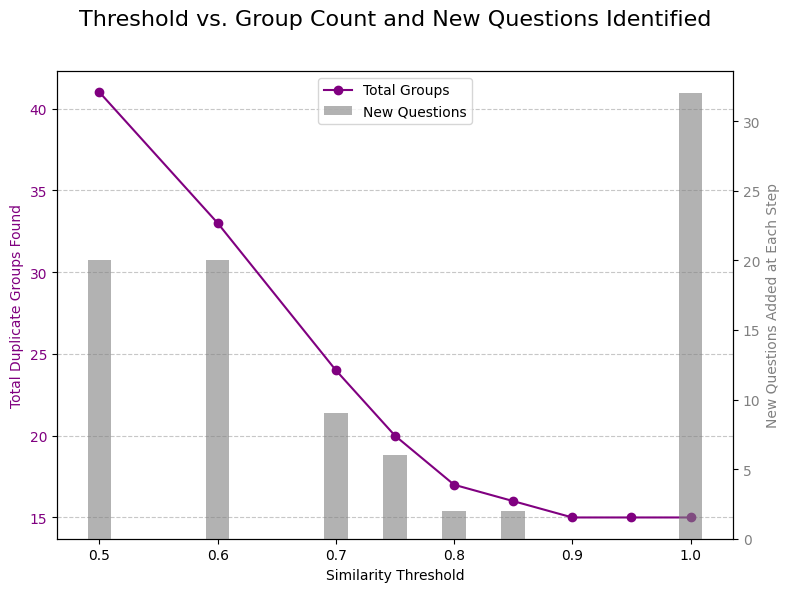

In [19]:
qq_threshold_summary_df_cleaned.sort_values(by='threshold', inplace=True)
x = qq_threshold_summary_df_cleaned['threshold']
y1 = qq_threshold_summary_df_cleaned['total_distinct_groups']
y2 = qq_threshold_summary_df_cleaned['new_questions_in_groups']

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot 1: Total Groups (Line Plot on the first y-axis)
color1 = 'purple'
ax1.set_xlabel('Similarity Threshold')
ax1.set_ylabel('Total Duplicate Groups Found', color=color1)
ax1.plot(x, y1, color=color1, marker='o', label='Total Groups')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Create the second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot 2: New Questions Added (Bar Plot on the second y-axis)
color2 = 'grey'
ax2.set_ylabel('New Questions Added at Each Step', color=color2)
ax2.bar(x, y2, color=color2, alpha=0.6, width=0.02, label='New Questions')
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('Threshold vs. Group Count and New Questions Identified', fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.96))

# Combine legends from both axes into one box
lines, labels = ax1.get_legend_handles_labels()
bars, bar_labels = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + bar_labels, loc='upper center')

plt.show()

This graph illustrates the trade-off between the strictness of the similarity threshold and the discovery of duplicate questions.
- The purple line tracks the cumulative number of unique duplicate groups identified as the threshold becomes more lenient (from the strictest value of 1.0 on the right to progressively lower values on the left).
- The grey bars represent the number of new questions added to the duplicate set at each specific threshold step, showing potentially more 'payoff' of near-duplicate questions with the lowering of the criteria. 

The key insight here is that duplicates tend to appear in clusters. At a threshold of 1.0, we see a large batch of exact semantic matches, likely missed earlier due to small differences such as punctuation. Another notable surge of near-duplicates appears upt to a threshold of 0.7. Beyond this point, the growing number of matches increasingly blends genuine near-duplicates with questions that are only topically similar. This pattern underscores the importance of examining lower thresholds to achieve a thorough and effective duplicate cleanup.

For a comprehensive quality review, athreshold of 0.5 will be used as a cutoff. This approach maximizes the capture of all potential similarities, ensuring that even subtly rephrased or thematically related questions are flagged for further verification.

>**Note**: In `v0` analysis, threshold reduction was carried out empirically and iteratively. The threshold was lowered incrementally, and the resulting duplicate groups were manually reviewed at each step. The review revealed that as the threshold approached 0.5, the flagged groups were increasingly made up of questions that were semantically different, not true near-duplicates. So, 0.5 was set as a practical lower bound, and the complex duplicates that slipped through were caught during the final data quality check. The improvement in the tokenizer but lemmatizing first results in more token overlaps so more accurate deduplication.

The detailed dataframe below provides the individual question and answer text. We can compare the questions and answers with the groups. In the head preview, showing the highest threshold (set at 1) results, we can see that the groups are in-fact duplicates.

In [20]:
qq_duplicate_groups_detailed_df_cleaned.head(8)

,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group
0,1.0,Thresh1.00_Group1,2,2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,True,True
1,1.0,Thresh1.00_Group1,2,235,159,What is Wronski Feint?,Pretending to dive for the Snitch.,True,True
19,1.0,Thresh1.00_Group10,2,539,356,What is Luna Lovegood’s father’s name?,Xenophilius Lovegood,True,True
20,1.0,Thresh1.00_Group10,2,1075,653,What is Luna Lovegood's father's name?,Xenophilius Lovegood.,True,True
21,1.0,Thresh1.00_Group11,2,569,375,What item in the Headmaster's Office allows yo...,The Pensieve,True,True
22,1.0,Thresh1.00_Group11,2,885,553,What item in the Headmaster's Office allows yo...,The Pensieve.,True,True
23,1.0,Thresh1.00_Group12,2,572,377,Why did the Werewolf Code of Conduct fail?,No Werewolves Signed,True,True
24,1.0,Thresh1.00_Group12,2,1045,638,Why did the Werewolf Code of Conduct fail?,No werewolves signed it.,True,True


But at the tail-end of the dataframe with the most relaxed threshold (set at 0.5), we can see that the in some cases (groups 11 & 14) the wording is very similar but the question is different. While in other cases (group 15) are duplicates but worded differently enough to not be identical. Here a more nuanced apporach is required and we will leverage the detailed review from `v0`.

In [21]:
# we need to filter to make sure we dont get the overlap groups from the higher thresholds.
new_groups_at_threshold = (qq_duplicate_groups_detailed_df_cleaned['newly_grouped_q']==True)
threshold = (qq_duplicate_groups_detailed_df_cleaned['threshold']==0.5)
qq_duplicate_groups_detailed_df_cleaned[new_groups_at_threshold & threshold].head(6)

,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group
353,0.5,Thresh0.50_Group11,2,101,77,A Nimbus is a type of what?,Broom,True,True
354,0.5,Thresh0.50_Group11,2,111,85,A Firebolt is a type of what?,Broom,True,True
359,0.5,Thresh0.50_Group14,2,118,88,What is the name of the werewolf who teaches D...,Remus Lupin,True,True
360,0.5,Thresh0.50_Group14,2,132,100,Who teaches Defense Against the Dark Arts duri...,Gilderoy Lockhart,True,True
361,0.5,Thresh0.50_Group15,2,130,98,Who is the author of 'Fantastic Beasts and Whe...,Newt Scamander,True,True
362,0.5,Thresh0.50_Group15,2,858,543,Who wrote Fantastic Beasts and Where to Find T...,Newt Scamander,True,True


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#421-identifying-near-duplicates-with-q-q-similarity" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 4.2 Quick Links</a>

### 4.2.5: "Golden record" selection
Using the definined hierarchical rules (best answer > best question > first occurrence), we can a select the best or "golden" record within each group. 

As a sanity check, we will compare these automated tags against the `v0` dataset. To ensure a fair comparison, we will first filter the v0 data to only include questions that are also in our current v1 dataset, i.e. excluding the new and edited questions that were added back since we haven't gotten to that stage with the current working dataset in `v1`.

In [22]:
# Sanity check: list of duplicate tagged IDs from the previous iteration (v0)
last_id_in_v1 = df_for_analysis['original_question_id'].max()                # The id of the last question in v1 as a limit
v0_duplicate_tags = (df_final_v0.loc[(df_final_v0['is_duplicate']) &         # Filter only questions tagged as duplicates AND
                                     (df_final_v0['original_question_id'] <= last_id_in_v1),  # id that are less than or equal to the last id in v1
                                     ['original_question_id'] 
                                     ]['original_question_id'].tolist()      # retrieve the original_question_ids as a list
)                    

print(f"Number of tagged duplicates in v0: {len(v0_duplicate_tags)}")

Number of tagged duplicates in v0: 100


There are a 100 questions tagged as duplicates in the `v0` dataset. We can use this as our baseline as to how many duplicates to expect and then compare the automated deduplication results in `v1`. The duplicates were tagged using a custom method based on the approach defined in [section 4.2.2](#422-approach)

In [23]:
df_for_analysis_dupe_tags = eda.tag_duplicates_with_override(df_for_analysis= cleaned_df_for_analysis, 
                                 results_df = qq_duplicate_groups_detailed_df_cleaned, 
                                 df_v0_cleaned= df_final_v0)

df_for_analysis_dupe_tags.sample(10, random_state=16)

Final dataset contains 559 unique questions to keep.
Final dataset flagged 100 questions as duplicates.


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword,is_duplicate
505,795,"Who is NOT in Gryffindor: Harry Potter, Ron We...",Draco Malfoy,"[who, be, gryffindor, harry, potter, ron, weas...","[draco, malfoy]","[who, be, gryffindor, harry, potter, ron, weas...","[who, be]",who,False
611,995,Who destroyed the Horcrux in Helga Hufflpuff's...,Hermione Granger,"[who, destroy, horcrux, helga, hufflpuff, cup]","[hermione, granger]","[who, destroy, horcrux, helga, hufflpuff, cup,...",[who],who,True
536,844,What is the name of the place where students b...,Diagon Alley,"[what, be, name, place, where, student, buy, s...","[diagon, alley]","[what, be, name, place, where, student, buy, s...","[what, be, name, where]",what,False
552,884,What is another name for Defodio?,Gouging Spell,"[what, be, another, name, defodio]","[gouge, spell]","[what, be, another, name, defodio, gouge, spell]","[what, be, name]",what,False
230,352,Who kills Dobby?,Bellatrix Lestrange,"[who, kill, dobby]","[bellatrix, lestrange]","[who, kill, dobby, bellatrix, lestrange]",[who],who,False
131,186,What was the Seeker originally called?,The Hunter,"[what, be, seeker, originally, call]",[hunter],"[what, be, seeker, originally, call, hunter]","[what, be]",what,False
199,301,What are the colors of Ravenclaw?,Blue and bronze,"[what, be, color, ravenclaw]","[blue, bronze]","[what, be, color, ravenclaw, blue, bronze]","[what, be]",what,False
253,385,Lily Potter once gave Professor Slughorn a bow...,Francis,"[lily, potter, give, professor, slughorn, bowl...",[francis],"[lily, potter, give, professor, slughorn, bowl...","[what, be, name]",what,False
257,390,What magical plant did Luna Lovegood have grow...,Dirigible Plums,"[what, magical, plant, do, luna, lovegood, hav...","[dirigible, plum]","[what, magical, plant, do, luna, lovegood, hav...","[what, do, have]",what,False
410,623,What was Harry Potter's middle name?,James,"[what, be, harry, potter, middle, name]",[james],"[what, be, harry, potter, middle, name, james]","[what, be, name]",what,False


The number of tagged duplicates matches `v0` but we can take a closer look to validate the results.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#421-identifying-near-duplicates-with-q-q-similarity" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 4.2 Quick Links</a>

#### 4.2.6: Validation of the tagging against `v0`

A custom method compares the `v0` and `v1` duplicate tags for each question and looks for discrepencies. Any identified discrepencies can be resolved through a review of disagreement dataframe. 

In [24]:
# compare the duplicate tags between v0 and v1
summary_results, disagreements_to_reivew_df= eda.validate_tagging_changes(new_df=df_for_analysis_dupe_tags,
                                                                    old_df=df_final_v0)

print(summary_results)
print(f"There are no disagreements between `v0` and `v1` tagging: {disagreements_to_reivew_df.empty}")

{'Agreed Duplicates': 100, 'Agreed Non-Duplicates': 559, 'Newly Flagged by Script': 0, 'Missed by Script': 0}
There are no disagreements between `v0` and `v1` tagging: True


The upstream changes (tokenizer and keyword grouping) did not introduce any new duplicates that were missed in `v0`. The common near-duplicates between `v0` and `v1` match. 

>**Limitation of the current manual approach**:
>
>Right now, identifying the near-duplicates in dataset relies on the manual review (`v0`) to ensure the highest possible quality for the initial static dataset. This is effective and efficient to develop the MVP of the game but it does have its limitations, i.e. long-term scalability and manual-review dependency. 
>
>Future development will address this by creating a smarter, automated near-duplicate detection system. This v2 tool will be developed in synergy with other advanced NLP features, leveraging:
> - Sentence-BERT for semantic understanding.
> - Custom NER to identify key entities.
> - Thematic categorization to narrow the search space.
> - Semantic answer checking for high-confidence validation.
>
> The goal is to build an intelligent system that learns from the initial high-quality baseline. This tool can then be used for any dataset maintenance and in the data ingestion pipeline, significantly reducing manual work and ensuring consistent quality as the dataset grows.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#421-identifying-near-duplicates-with-q-q-similarity" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 4.2 Quick Links</a>

#### 4.2.7: Remove the duplicates

We can now remove the tagged near-duplicates.

In [25]:
# Delete duplicates and print a summary

processed_df_for_analysis = df_for_analysis_dupe_tags.copy()
processed_df_for_analysis = processed_df_for_analysis[~processed_df_for_analysis['is_duplicate']]  # keep only False
processed_df_for_analysis = processed_df_for_analysis.drop(columns='is_duplicate')

before = df_for_analysis_dupe_tags.shape[0]
after = processed_df_for_analysis.shape[0]
difference = before - after

print('Summary of deduplication\n' + '-'*30 )
print(f'Number of documents BEFORE near-duplicates were removed: {before}')
print(f'Number of documents AFTER near-duplicates were removed: {after}')
print(f'Number of documents removed: {difference}')
print('-'*30 + '\nProcessed dataset head:')
display(processed_df_for_analysis.head())

Summary of deduplication
------------------------------
Number of documents BEFORE near-duplicates were removed: 659
Number of documents AFTER near-duplicates were removed: 559
Number of documents removed: 100
------------------------------
Processed dataset head:


,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword
0,0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang.","[what, be, three, european, wizarding, school,...","[hogwarts, beauxbatons, durmstrang]","[what, be, three, european, wizarding, school,...","[what, be]",what
1,1,When was Hogwarts founded?,10th century,"[when, be, hogwarts, found]","[10th, century]","[when, be, hogwarts, found, 10th, century]","[when, be]",when
2,2,What is a Wronski Feint?,Pretending to dive for the Snitch,"[what, be, wronski, feint]","[pretend, dive, snitch]","[what, be, wronski, feint, pretend, dive, snitch]","[what, be]",what
3,3,You wouldn't know anything about this. Name a ...,Using polish,"[know, anything, name, method, make, broom, go...","[use, polish]","[know, anything, name, method, make, broom, go...",[name],name
4,4,Harry first took the Knight Bus in The Prisone...,14 sickles.,"[harry, first, take, knight, bus, prisoner, az...","[14, sickle]","[harry, first, take, knight, bus, prisoner, az...","[how, do]",how


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#421-identifying-near-duplicates-with-q-q-similarity" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to Section 4.2 Quick Links</a>

### 4.3: Answer-Answer (A-A) comparison
A grouping of similar answers can provide another perspective of analysis. 

Removing the near-duplicates questions earlier changes the constitution of the dataset. This means we need to perform the vectorization and similarity score calculation again.

In [26]:
# Key variables
column_name = 'combined_unique_tokens'
ngram_range = (1,3)
stop_words = [] # in case there are additional words.
# Default min_df and max_df

# 1. combine the combined unique keyword column into a string.
df_tfidf_cs_processed = processed_df_for_analysis.copy()
df_tfidf_cs_processed['all_keywords_str'] = df_tfidf_cs_processed[column_name].apply(lambda token_list: ' '.join(token_list))

# 2. Initialize the tf-idf vectorizer:
vectorizer_global = TfidfVectorizer(stop_words= stop_words, ngram_range= ngram_range)

# 3. Fit the vectorizer on the combined tokens
vectorizer_global.fit(df_tfidf_cs_processed['all_keywords_str'])

# 4. Transform the question and answer tokens with the vectorizer to get their respective sparse matrices.
X_questions_p, Y_answers_p = eda.transform_for_similarity_check(df_tfidf_cs_processed, vectorizer_global)

# 5. Create a full similarity matrix
aa_similarity_matrix_p = cosine_similarity(Y_answers_p, Y_answers_p)
# Print summary descriptive statistics for the similarity matrix:
eda.print_similarity_matrix_stats(aa_similarity_matrix_p )


--- Statistics for Pairwise Similarity ---
* Original matrix shape: (559, 559)
* Number of unique pairwise scores (off-diagonal): 155961
* Percentage of non-zero scores: 0.32%

Descriptive statistics for non-diagonal scores:
 --------------------------------------------------
count    155961.0000
mean          0.0009
std           0.0237
min           0.0000
25%           0.0000
50%           0.0000
65%           0.0000
66%           0.0000
75%           0.0000
90%           0.0000
95%           0.0000
99%           0.0000
max           1.0000
dtype: float64
--------------------------------------------------


The answers are mostly unique (99% similarity score is 0) with a small minority of repeating answers (max similarity score is 1).

We can take a closer look at the repeated answers using the same duplicate grouping method (cosine similarity score and graph analysis) we used for the question-to-question comparison earlier.

In [27]:
# Create groupings of near-duplicate answers using the custom method from eda_scripts
threshold_list= [1.00]
aa_duplicate_groups_detailed_df, aa_threshold_summary_df = eda.get_duplicates_with_graph(processed_df_for_analysis, threshold_list, aa_similarity_matrix_p)
aa_threshold_summary_df[['threshold','total_distinct_groups','new_groups_at_this_threshold',
                         'total_questions_in_groups','new_questions_in_groups' ]]

,threshold,total_distinct_groups,new_groups_at_this_threshold,total_questions_in_groups,new_questions_in_groups
0,1.0,36,36,79,79


There are 79 questions that have repeated answers. There are 36 common answers among these questions. Let's take a closer look at the most frequent appearing answers in the dataset.

In [28]:
aa_duplicate_groups_detailed_df.sort_values(by='group_size',ascending=False).head(9)

,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group
36,1.0,Thresh1.00_Group16,5,973,517,Who makes laws for the magical world?,The Ministry of Magic.,True,True
35,1.0,Thresh1.00_Group16,5,786,434,What replaced the Wizards' Council?,The Ministry of Magic.,True,True
34,1.0,Thresh1.00_Group16,5,563,326,Where is the British and Irish Quidditch Leagu...,The Ministry of Magic,True,True
33,1.0,Thresh1.00_Group16,5,551,321,Where is the Hall of Prophecy?,Ministry of Magic,True,True
32,1.0,Thresh1.00_Group16,5,224,139,What's the name of the magical government in t...,The Ministry of Magic,True,True
39,1.0,Thresh1.00_Group18,4,299,178,Which of the Hogwarts ghosts is Peeves afraid of?,The Bloody Baron,True,True
42,1.0,Thresh1.00_Group18,4,997,524,Who killed the Grey Lady?,The Bloody Baron,True,True
41,1.0,Thresh1.00_Group18,4,968,516,Who was in love with Helena Ravenclaw?,The Bloody Baron,True,True
40,1.0,Thresh1.00_Group18,4,558,323,Who is Slytherin's patron ghost?,Bloody Baron,True,True


The top two most common answers are *"Ministry of Magic"* (5 occurences) and *Bloody Baron* (4 occurences). The results also confirm that the deduplication worked since these answers are a result of different questions. We can get a better overview by plotting the answers against their frequencies.

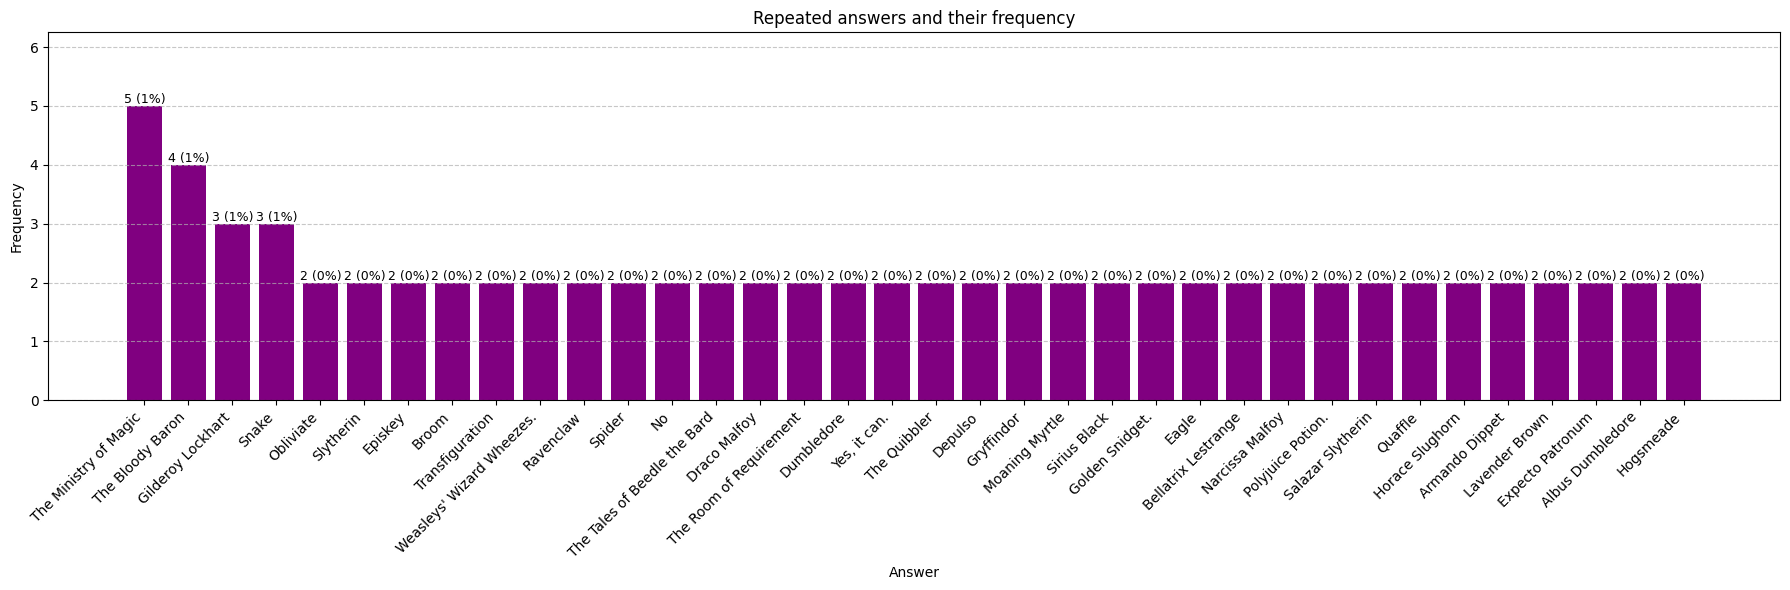

In [29]:
grouped = (
    aa_duplicate_groups_detailed_df.groupby("group_id").agg(
        answer=("answer_text", "first"),
        group_size=("group_size", "first")).reset_index()
    ).sort_values(by='group_size', ascending=False)

# Convert to series: answers as index, group_size as values
answer_counts = pd.Series(grouped.group_size.values, index=grouped.answer)
# Total items for percentages 
total_items = processed_df_for_analysis.shape[0]
# plot with helper
eda.plot_categorical_distribution(
    category_counts=answer_counts,
    total_items=total_items,
    title="Repeated answers and their frequency",
    xlabel="Answer",
    ylabel="Frequency",
    color="purple",
    figsize=(18,6))

From the A-A similarity results and the plot, we can see:

1. **High topic diversity**: In the dataset with 559 questions, 86% (or 480 questions) have unique answers. The other 14% (79 questions), have 36 repeating answers predominently only showing up twice. The answers we see are very specific to the Harry Potter universe and include character names, locations, creatures, Hogwart houses, spells and other magical terms.

2. **Text processing is effective**: Answers with slight variations (e.g. "Ministry of Magic" vs "The Ministry of Magic" in group 16 and "Snake" vs. "Snakes" in group 1) are being grouped together as the same entity. This is because the lemmatization and tokenization are working well and will provide a solid foundation for the planned advanced NLP work ahead.

3. **Improvements in data quality**: By removing the problematic and near-duplicate questions, the frequency of the *"The Blood Baron"* phrase has dropped from *8 times* in the [preliminary EDA](../notebooks/01_cleaning_and_eda.ipynb#752-top-20-n-grams-in-the-answers) to only **4 times** in the plot above. From the A-A grouping dataframe snapshot above, we can see that these are all from different questions (group 18).

4. **Limitations in recognizing conceptually identical answers**: the text processing is great at finding lexical matches from the token but it miscategorizes "Albus Dumbledore" and "Dumbledore" as different answers even though they refer to the same person. This is where the advanced NLP work (custom NER and semantic answer checking) will shine.

5. **Repeating YN answers are expected**: We would expect to see *"No"* and *"Yes"* to appear several times are the YN are specifically designed to elicit these responses.

5. **Uncovered a possible quality issue**: The answer *"Goldent Snidget"* appears twice in the dataset. This could be referring to a *golden snitch* instead? We can take a closer look at the group to confirm.

In [30]:
# 1. get the group id. Note: we can't just filter based on answer because the answer_texts differ slightly
groupid = aa_duplicate_groups_detailed_df.loc[aa_duplicate_groups_detailed_df['answer_text']=='Golden Snidget','group_id'].iloc[0]
# Look up the full group
aa_duplicate_groups_detailed_df[aa_duplicate_groups_detailed_df['group_id']==groupid]

,threshold,group_id,group_size,original_question_id,matrix_position,question_text,answer_text,newly_grouped_q,new_or_expanded_group
51,1.0,Thresh1.00_Group23,2,476,283,What creature did the Wizards’ Council make a ...,Golden Snidget.,True,True
52,1.0,Thresh1.00_Group23,2,661,377,Which creature was used in Quidditch before be...,Golden Snidget,True,True


Interesting! The 'Golden Snidget' questions are valid within Harry Potter lore, coming primarily from *Quidditch through the Ages* [[1]](#11-references). Since the book is authored by J.K. Rowling, it is considered canon. Nice to see some difficult and niche questions in the dataset! It definitely stumped me for a bit.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 5: Feature engineering for downstream tasks
Based on the insights from the exploratory data analysis (EDA), new features can be used to standardize the dataset and support more advanced processing. Key additions include:

1. **Length Metrics (`question_length`, `answer_length`)**: Word counts for questions and answers providing baseline measures of complexity and inputs for question classification logic.

2. **Question Classification (`question_type`)**: Each question was categorized into one of four types, namely, Factual Recall (FR), Explanatory (EX), Yes/No (YN), or Multiple Choice (MCQ). This classification will help with creating nuanced answer-checking methods. A simpler approach can work for FR, YN, and MCQs while the EX types would need a more comprehensive and flexible approach. 

3. **Answer Typing (`answer_type`)**: Classify each answer as text, numeric, date, or year. This allows the answer checker to handle different data formats intelligently (e.g., handling date variations or accepting "fourteen" for "14" from players).

## 5.1: Length metrics

We can use a custom method to get word counts for both questions and answers.

In [31]:
# Add columns for question and answer lengths (word counts) using the custom method from eda_scripts
processed_df_for_analysis['question_length'] = eda.get_clean_word_counts(processed_df_for_analysis, "question")
processed_df_for_analysis['answer_length'] = eda.get_clean_word_counts(processed_df_for_analysis, "answer")
# Review update
display(processed_df_for_analysis[['question','answer','question_length','answer_length']].head())

,question,answer,question_length,answer_length
0,What are the three European wizarding schools ...,"Hogwarts, Beauxbatons, and Durmstrang.",13,4
1,When was Hogwarts founded?,10th century,4,2
2,What is a Wronski Feint?,Pretending to dive for the Snitch,5,6
3,You wouldn't know anything about this. Name a ...,Using polish,16,2
4,Harry first took the Knight Bus in The Prisone...,14 sickles.,22,2


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.2: Classify questions into types

The [initial EDA](../notebooks/01_cleaning_and_eda.ipynb) revealed a strong correlation between a question's main interrogative keyword and its functional question type. This insight allows us to build a rule-based classifier to categorize each question, which is essential for developing a more intelligent and accurate answer-checking process.

The classification logic is as follows:
- **Factual Recall (FR)**: Questions starting with `what`, `which`, `who`, `where`, `when`, and `name` consistently ask for specific, factual information.
- **Explanatory (EX)**: Questions starting with `why` require a descriptive or explanatory answer.
- **Yes/No (YN)**: Questions starting with auxiliary verbs like `be`, `can`, and `do` are typically structured for a Yes/No or True/False response.

### Special considerations:

- **The keyword `how`** is unique in that it can introduce either a quantitative FR question (e.g., `how many...`) or an EX question (e.g., `how did...`). While initially simplified as FR, these question now need a more nuanced classification to distinguish between these two uses.
- **Multiple-Choice Questions (MCQ)** were identified by phrases like `which of the following...`. However, the EDA revealed significant quality issues with these questions likely due to web scraping errors. They have been temporarily removed ([section 4.2.3](#423-initial-quality-filtering)) and the edited, completed questions will be reintegrated using the data ingestion pipeline.

To validate these categories, we can start by generating descriptive statistics for each keyword group reusing custom methods from eda_scripts.

In [32]:
# We can recalculate the key metrics by keywords for the updated, processed dataset

# Keywords list of which terms to summarize in the table
keywords_list = ['what', 'which', 'who', 'how', 'where', 'when', 'name', 'why', 'be','do', 'can']
# List of keywords that will be categorized as 'factual recall'
FR_keywords = ['what', 'which', 'who', 'how', 'where', 'when', 'name' ]

# 1. Create a master summary table based on keyword lists using a custom function from teh eda_scripts module
full_keyword_summary_df = eda.create_comprehensive_summary_df(keywords_list, FR_keywords, processed_df_for_analysis)
# 2. Display the correlation summary table using a view helper function from the eda_scripts module
eda.display_correlation_summary(full_keyword_summary_df)

INFO: Correlation for 'do' skipped. All question (or answer) lengths are the same so there is no variance to measure.
INFO: Correlation for 'can' skipped. All question (or answer) lengths are the same so there is no variance to measure.

Correlation Summary Table by Question Keywords:


,Question Keyword,question_type,Keyword Count,(%) of total,Mean Question Length,Mean Answer Length,Pearson's r,P-value,Interpretation
0,what,Factual-Recall,310,55.0,10.0,2.0,0.143,0.011,Statistically significant (correlation is Very...
2,who,Factual-Recall,98,18.0,9.0,3.0,0.155,0.128,Not statistically significant (r=0.155)
1,which,Factual-Recall,75,13.0,10.0,2.0,0.105,0.368,Not statistically significant (r=0.105)
4,where,Factual-Recall,24,4.0,9.0,3.0,0.470,0.020,Statistically significant (correlation is Mode...
3,how,Factual-Recall,18,3.0,12.0,5.0,0.089,0.725,Not statistically significant (r=0.089)
5,when,Factual-Recall,15,3.0,10.0,3.0,0.251,0.367,Not statistically significant (r=0.251)
6,name,Factual-Recall,9,2.0,14.0,8.0,0.320,0.401,Not statistically significant (r=0.320)
7,why,Non-Factual,4,1.0,10.0,6.0,0.128,0.872,Not statistically significant (r=0.128)
9,do,Non-Factual,2,0.0,7.0,2.0,NaN,NaN,Insufficient variance for correlation
10,can,Non-Factual,2,0.0,8.0,3.0,NaN,NaN,Insufficient variance for correlation


Excluding `how` for now, 95% are factual-recall type. The other types are a small minority (YN and EX). The analysis shows there is a significant opportunity to enhance the diversity and player engagement of the trivia dataset. Currently, the question types are imbalanced where a great majority  are simple factual recall. While these are essential, increasing the number of other types, espescially Explanatory (EX) questions is important. These questions encourage players to engage with deeper aspects of the lore which would create a richer and more satisfying gameplay experience for dedicated fans.

Now let's take a closer look at the `how` questions.

In [33]:
# filter to just the `how` questions for review
filtered_how_df = processed_df_for_analysis[processed_df_for_analysis['main_keyword']=='how']
filtered_how_df[['original_question_id','question','question tokens','answer','answer_length']].sort_values(by='original_question_id')

,original_question_id,question,question tokens,answer,answer_length
4,4,Harry first took the Knight Bus in The Prisone...,"[harry, first, take, knight, bus, prisoner, az...",14 sickles.,2
32,40,How is Quodpot different from Quidditch?,"[how, be, quodpot, different, quidditch]",The ball explodes,3
37,47,How often does a Streeler's shell change colour?,"[how, often, do, streeler, shell, change, colour]",Every Hour,2
120,169,How is the Grey Lady related to Rowena Ravenclaw?,"[how, be, grey, lady, relate, rowena, ravenclaw]",She's Rowena's daughter.,5
121,171,How do you greet a Hippogriff?,"[how, do, greet, hippogriff]",With a bow,3
136,193,"In Harry Potter and the Prisoner of Azkaban, h...","[harry, potter, prisoner, azkaban, how, do, he...",He jumps on Ron's head at the Magical Menagerie.,10
210,320,How did Harry first arrive (and ultimately dep...,"[how, do, harry, first, arrive, ultimately, de...",Flying Motorobike,2
305,453,How should your completed Scintillation Soluti...,"[how, should, complete, scintillation, solutio...",Sparkling.,1
317,475,How did Mad-Eye Moody punish Draco Malfoy for ...,"[how, do, mad, eye, moody, punish, draco, malf...",He turned Draco into a ferret.,6
346,522,How is mail delivered in the wizarding world?,"[how, be, mail, deliver, wizarding, world]",By owl post.,3


Interesting, we can see that the answer length can be a reasonable indicator of the question being FR or EX but it there is no clear dividing line. Instead we can modify the classifier to categorize the quantitative FR questions based on the observed "keyword phrases" (e.g. `how many`) and the remainder classified as `EX`. Centralized lists for each keyword type are placed in the [DS constants module](../src/ds_utils/ds_constants.py).

In [34]:
## Updated keyword lists for searching different types of questions.
print('Centralized list of keywords for categorization of questions into types:\n'+'-'*80)
print(f'- FR: Factual recall keywords: {const.FACTUAL_RECALL_KEYWORDS}')
print(f'- FR: "How" factual-recall n-grams: {const.FACTUAL_HOW_NGRAMS}')
print(f'- EX: Explanatory type question keywords: {const.EXPLANATORY_KEYWORDS} + remaining "how"')
print(f'- YN: Yes/No type question keywords: {const.YES_NO_KEYWORDS}')

Centralized list of keywords for categorization of questions into types:
--------------------------------------------------------------------------------
- FR: Factual recall keywords: {'when', 'who', 'where', 'name', 'what', 'which'}
- FR: "How" factual-recall n-grams: {'how old', 'how much', 'how long', 'how many'}
- EX: Explanatory type question keywords: {'why'} + remaining "how"
- YN: Yes/No type question keywords: {'true', 'can', 'did', 'is', 'were', 'false', 'do', 'be', 'are', 'was'}


A rule-based classifier was used to categorize the questions based on these keyword lists as follows:
- *Multiple-choice questions* are first identified by looking for patterns in questions. First it looks for leading n-grams, such as "Which of the following" and second a list of options provided to selected for any questions not captured in the first step.
- *Primary keywords*: The `main_keyword` is then checked against specific lists to identify FR, EX, and YN questions.
- *Special `how` Logic*: If the keyword is `how`, the full question text is scanned for specific n-grams (e.g., "how many") to classify it as FR. All other how questions are classified as EX.
- *Fallback*: Any question not matching the above criteria is assigned to an Other category for further analysis.

In [35]:
# 1. Apply the categorization function to each row (axis=1)
processed_df_for_analysis['question_type'] = processed_df_for_analysis.apply(eda.categorize_question, axis=1)
# 2. Check the value counts
processed_df_for_analysis['question_type'].value_counts()

question_type
FR     530
EX      20
YN       6
MCQ      3
Name: count, dtype: int64

All questions were categorized successfully (no `other` category). We can take a closer look to see the categorization of the `how` questions.

In [36]:
# Filter for `how` questions to see the distribution of types
how_q = processed_df_for_analysis[processed_df_for_analysis['main_keyword']=='how'].sort_values(by='question_type',ascending=False)
how_q[['original_question_id','question','question_type','answer','answer_length']]

,original_question_id,question,question_type,answer,answer_length
4,4,Harry first took the Knight Bus in The Prisone...,FR,14 sickles.,2
451,707,Quidditch players are constantly at risk of in...,FR,700.,1
32,40,How is Quodpot different from Quidditch?,EX,The ball explodes,3
551,882,How do you get into the Room of Requirement?,EX,While thinking about what you need the room to...,18
522,819,How do fairies communicate?,EX,By buzzing.,2
457,718,How do first years get from the Hogsmeade trai...,EX,They take boats over the lake.,6
450,706,How does Dumbledore escape from his office whe...,EX,"He grabs Fawkes’s tail, and they disappear in ...",13
413,629,How is Bellatrix related to Tonks?,EX,Tonks is Bellatrix's niece.,5
396,601,Before the start of his second year at Hogwart...,EX,With a flying car,4
346,522,How is mail delivered in the wizarding world?,EX,By owl post.,3


Two of the how questions were categorized as Factual Recall (FR), while the rest were classified as Explanatory (EX). The classifier correctly identified phrases like ‘how much’ and ‘how many’ as FR. For the EX questions, even when answers are relatively short, they tend to be descriptive and allow for multiple valid expressions. For example, for Q.718, acceptable answers might include *‘they are rowed across the lake’* or *‘Hagrid and other staff row them across the lake'*.

Now let's take a look at the YN question types.

In [37]:
# YN type questions
processed_df_for_analysis[processed_df_for_analysis['question_type']=='YN']

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword,question_length,answer_length,question_type
233,355,True or false: Harry Potter and the Deathly Ha...,True! The run time is just 130 minutes.,"[true, false, harry, potter, deathly, hallows,...","[true, run, time, be, 130, minute]","[true, false, harry, potter, deathly, hallows,...","[true, false, be]",true,17,8,YN
424,651,Is it safe to drink water conjured by Aguamenti?,"Yes, it's safe to drink.","[be, safe, drink, water, conjure, aguamenti]","[yes, safe, drink]","[be, safe, drink, water, conjure, aguamenti, yes]",[be],be,9,6,YN
436,676,Can the Extinguishing Charm be used to put out...,"Yes, it can.","[can, extinguishing, charm, be, use, put, drag...","[yes, can]","[can, extinguishing, charm, be, use, put, drag...","[can, be]",can,11,3,YN
507,797,Can Ascendio be used underwater?,"Yes, it can","[can, ascendio, be, use, underwater]","[yes, can]","[can, ascendio, be, use, underwater, yes]","[can, be]",can,5,3,YN
514,805,Did the werewolf code of conduct work?,No,"[do, werewolf, code, conduct, work]",[no],"[do, werewolf, code, conduct, work, no]",[do],do,7,1,YN
583,933,Do ancient runes have magical properties thems...,"No, they don't.","[do, ancient, rune, have, magical, property]",[no],"[do, ancient, rune, have, magical, property, no]","[do, have]",do,7,4,YN


Again, we can see that these questions have also been correctly categorized; all answers are Yes, No, or True.
We can now look at the three Multiple-Choice Questions (MCQ) flagged by the classifier.

In [38]:
# MCQ type questions
processed_df_for_analysis[processed_df_for_analysis['question_type']=='MCQ']

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword,question_length,answer_length,question_type
222,341,"In the Quidditch World Cup, Ireland's team had...",Troy,"[quidditch, world, cup, ireland, team, have, t...",[troy],"[quidditch, world, cup, ireland, team, have, t...","[have, which]",which,22,1,MCQ
483,749,"Who is NOT in Slytherin: Lavender Brown, Pansy...",Lavender Brown,"[who, be, slytherin, lavender, brown, pansy, p...","[lavender, brown]","[who, be, slytherin, lavender, brown, pansy, p...","[who, be]",who,14,2,MCQ
505,795,"Who is NOT in Gryffindor: Harry Potter, Ron We...",Draco Malfoy,"[who, be, gryffindor, harry, potter, ron, weas...","[draco, malfoy]","[who, be, gryffindor, harry, potter, ron, weas...","[who, be]",who,14,2,MCQ


All three are correctly identified as MCQs. They are complete so remained in the dataset.
Finally we can sample the EX and FR types to confirm that they are also categorized correctly.

In [39]:
# Sample of FR type questions
processed_df_for_analysis.loc[processed_df_for_analysis['question_type']=='FR',
                              ['original_question_id','question','question_type','answer','answer_length']
                              ].sample(5)

,original_question_id,question,question_type,answer,answer_length
125,177,What spell works on the Whomping WIllow to sto...,FR,The Freezing Charm,3
415,633,Who wrote Unfogging the Future?,FR,Cassandra Vablatsky,2
585,936,Who is the Transfiguration Professor?,FR,Minerva McGonagall,2
451,707,Quidditch players are constantly at risk of in...,FR,700.,1
74,97,Which part of the asphodel plant is used in Dr...,FR,Root,1


In [40]:
# Sample of EX type questions
processed_df_for_analysis.loc[processed_df_for_analysis['question_type']=='EX',
                              ['original_question_id','question','question_type','answer','answer_length']
                              ].sample(5)

,original_question_id,question,question_type,answer,answer_length
317,475,How did Mad-Eye Moody punish Draco Malfoy for ...,EX,He turned Draco into a ferret.,6
396,601,Before the start of his second year at Hogwart...,EX,With a flying car,4
7,9,Why did student initially think Harry was the ...,EX,He can speak Parseltongue,4
32,40,How is Quodpot different from Quidditch?,EX,The ball explodes,3
413,629,How is Bellatrix related to Tonks?,EX,Tonks is Bellatrix's niece.,5


These dataset samples suggest the question classifier is working well in capturing the distinctions across question types and generalizes well.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 5.3:  Engineering `answer_type` for smarter validation

To enable more sophisticated and flexible answer validation, the simple `is_numeric` boolean flag has been replaced with a multi-class `answer_type` column. A hierarchical, rule-based classifier was developed to categorize each answer as `numeric`, `year`, `date`, or `text`. This distinction is necessary because each type requires a unique validation strategy: `date`, `year`, and `numeric` answers can be checked directly, while text answers will rely on contextual NLP features to be developed [later](../notebooks/04-NER_implementation.ipynb).

This new approach builds upon the initial standardization of numeric answers from [v0](../notebooks/v0/01-cleaning_fulleda_v0.ipynb) 
In a previous step ([section 4.2.3](#423-initial-quality-filtering)), purely numeric answers were removed for reformatting and will be reincorporated later via the data ingestion pipeline. The new answer classifier's main role is to correctly identify the `year` and `date` formats among the remaining data, while also acting as a safety net to catch any numeric answers that were missed during the initial filtering.

We can confirm that the numeric questions were removed with a two-step check:
 1. Verify that no entries in the current dataset have the `is_numeric` flag set to `True`.
 2. Cross-reference with the `v0` dataset to ensure that none of the `original_question_ids` previously marked as numeric are present in the current working dataset. 

In [41]:
## Check 1: confirm no numeric answers in the current dataset
# Add the is `is_numeric` column based on v0
processed_df_for_analysis = pd.merge(processed_df_for_analysis, df_final_v0[['original_question_id','is_numeric_answer']], on='original_question_id', how='left')
# Check the value counts
processed_df_for_analysis['is_numeric_answer'].value_counts()

is_numeric_answer
False    559
Name: count, dtype: int64

In [42]:
## Check 2: confirm no original_question_ids from v0 that were tagged as numeric are present in the current dataset

numeric_ans_id_v0 = list(df_final_v0.loc[df_final_v0['is_numeric_answer']==True, 'original_question_id'])
processed_df_for_analysis['original_question_id'].isin(numeric_ans_id_v0).sum()

np.int64(0)

We can see that all the current values in the `is_numeric` column are `False` and none of the `original_question_ids` for the questions with numeric answers are present. Now, let's apply the classifier and examine the distribution of the newly created answer types.

In [43]:
# 2. Classify the remaining questions into 'date', 'year', 'text', into a new column 'answer_type' using the custom function from eda_scripts
processed_df_for_analysis['answer_type'] = processed_df_for_analysis.apply(eda.classify_answer_type, axis=1)
# 3. Summarize the results
processed_df_for_analysis['answer_type'].value_counts()
# processed_df_for_analysis.sample(10, random_state=16)

answer_type
text       552
year         3
date         3
numeric      1
Name: count, dtype: int64

So an additional seven questions, including one new numeric answer that was missed were tagged other than `text`. This can be another opportunity to balance the dataset with more variety of questions based on their answer type. We can take a closer look at these results to confirm that the categorizationi is correct.

In [44]:
# Review the non-text answers
processed_df_for_analysis.loc[processed_df_for_analysis['answer_type']!='text', ['question','answer','answer_type']]

,question,answer,answer_type
1,When was Hogwarts founded?,10th century,year
105,When did the wildcat gargoyle strike the place?,1911,year
165,When is Neville's birthday?,July 30,date
396,Quidditch players are constantly at risk of in...,700.,numeric
412,When was Quidditch invented?,1050 AD,year
495,On what date did the Battle of Hogwarts end wi...,"May 2, 1998",date
520,When is Harry's birthday?,"July 31, 1980.",date


The different formats of year and date are correctly categorized, including the partial ones as well different formats.

In [45]:
# Review a sample of text answers
processed_df_for_analysis.loc[processed_df_for_analysis['answer_type']=='text', 
                              ['question','answer','answer_type','is_numeric_answer']].sample(10, random_state=59)

,question,answer,answer_type,is_numeric_answer
28,What does the Vermillious spell make appear fr...,Red Sparks,text,False
141,Who is the Astronomy professor?,Professor Sinistra,text,False
479,What is the correct way to open the Monster Bo...,Stroke the spine,text,False
468,What is Fred Weasley’s chosen code name on Pot...,Rapier.,text,False
435,What potion is used to rid yourself of Doxies?,Doxycide,text,False
477,How do you get into the Room of Requirement?,While thinking about what you need the room to...,text,False
9,What is the root language of any spells?,Latin,text,False
348,Where does the Sopophorous Plant grow?,Gloomy marshlands.,text,False
134,What is the name of Hagrid's boarhound dog?,Fang,text,False
177,What's one form of Hex-Deflection?,Salvio Hexia,text,False


The text sampling also confirms the tags look good. For now we will keep the `is_numeric` column as an extra validation step till the new questions are added. Then we can remove the column in one go. We can, however, change the question and answer type columns to `category` type.

In [46]:
# change column datatypes
processed_df_for_analysis['question_type'] = processed_df_for_analysis['question_type'].astype('category')
processed_df_for_analysis['answer_type'] = processed_df_for_analysis['answer_type'].astype('category')
processed_df_for_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   original_question_id    559 non-null    int64   
 1   question                559 non-null    string  
 2   answer                  559 non-null    string  
 3   question tokens         559 non-null    object  
 4   answer tokens           559 non-null    object  
 5   combined_unique_tokens  559 non-null    object  
 6   interrogative_keywords  559 non-null    object  
 7   main_keyword            559 non-null    object  
 8   question_length         559 non-null    int64   
 9   answer_length           559 non-null    int64   
 10  question_type           559 non-null    category
 11  is_numeric_answer       559 non-null    bool    
 12  answer_type             559 non-null    category
dtypes: bool(1), category(2), int64(3), object(5), string(2)
memory usage: 45.8+ KB


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 6: Preliminary status map of the dataset

With the new features added, we can generate a quick snapshot of the dataset as it currently stands, before adding the new questions, to have a point of comparison.

## Trivia Dataset Status Map

---

### 1. Key Metrics

**- Total Unique Questions in Final Dataset:** 559<br>**- Net Change in Questions:** -720<br>   *(Note: A positive number indicates new questions were added; a negative number indicates questions were removed.)*<br>**- Answer Type Distribution:** text (552), date (3), year (3), numeric (1)<br>


### 2. Breakdown by Question Type

,Question Count,Percentage (%),Unique Answer Count,Median Q Len,Median A Len,Top Answer Keywords,Top main_keyword,Unassigned Keyword Count
Question Type,,,,,,,,
FR,530,94.8%,500,9.0,2.0,"weasley (10), professor (10), magic (7)","what (310), who (96), which (74)",0
EX,20,3.6%,20,9.0,4.0,"draco (2), fly (2), speak (1)","how (16), why (4)",0
YN,6,1.1%,6,8.0,3.5,"yes (3), no (2), run (1)","can (2), do (2), true (1)",0
MCQ,3,0.5%,3,14.0,2.0,"troy (1), lavender (1), brown (1)","who (2), which (1)",0



Note:
Question types: FR (Factual Recall), EX (Explanatory), YN (Yes/No or True/False), MCQ (Multiple Choice Question)



### 3. Visualizations by Question Type

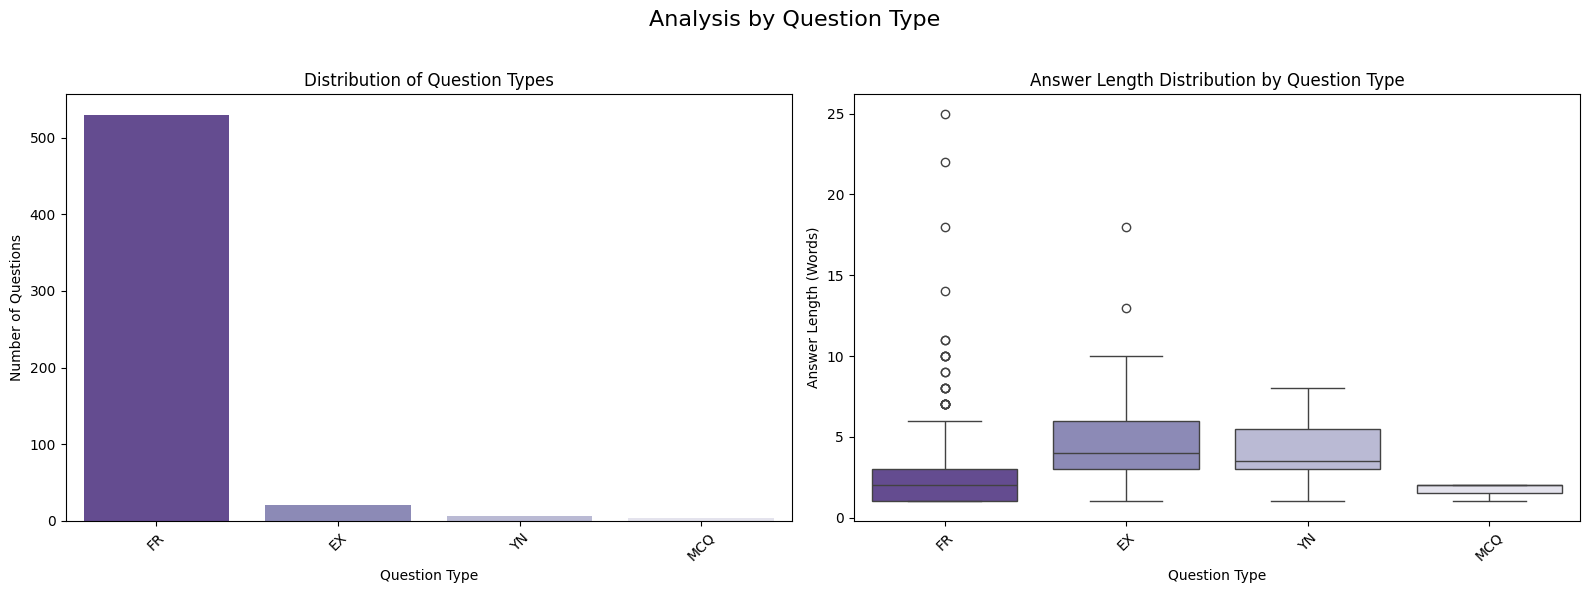


---

In [47]:
# Upload saved dataset metrics from notebook 1 to get initial raw question count:
path = nb_cfg.METRICS_DIR/'nb1_summary.json'
with open(path) as f:
    data = json.load(f)
original_raw_count = data['raw_dataset_row_count'] 
# Generate the status map
eda.generate_dataset_status_report(processed_df_for_analysis, initial_total=original_raw_count)

The status map reveals two key insights about the dataset. First, about 56% of the original questions were removed during curation, leaving 559 verified questions. Second, the distribution of question types is uneven. Factual Recall (FR) questions dominate, while Explanatory (EX) and Yes/No (YN) questions are fewer but much more diverse in answer length. This suggests an opportunity to make the game more engaging by including more of these varied question types going ahead.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 7: Data ingestion pipeline

A data ingestion pipeline will be built to ensure a reliable and standardized process for growing the dataset. Using this pipeline, we will reintroduce the edited questions that have been set aside and add 100 new questions to replace the ones permanently removed during quality checks. 

This process involves four key steps:

1. Standardizing the format and requirements for new questions.
2. Developing and implementing the pipeline logic.
3. Ingesting the new and edited questions.
4. Generating a final status report for the complete, updated dataset.

>#### Methodology update: from v0 iteration to v.0.1 
> A key improvement in this pipeline will be the replacement of the simple `is_numeric` input flag. The new pipeline will be self-sufficient, automatically generating a more detailed answer_type column (text, numeric, date, year) for all incoming data.

## 7.1: Standardized requirements for new additions to the trivia dataset

##### A. Content & Source Guidelines
Going forward, the questions need to be derived from appropriate sources.
| Category                  | Details                                                                                          |
|---------------------------|--------------------------------------------------------------------------------------------------|
| **Primary Focus**         | Trivia based on the seven main Harry Potter books.                                               |
| **Accepted Secondary Sources** | - The eight Harry Potter movies and Fantastic Beasts films.  <br> - *Quidditch Through the Ages* and *Fantastic Beasts and Where to Find Them*. <br> - J.K. Rowling-approved content from Pottermore / Wizarding World. |
| **Explicitly Excluded Sources** | - Non-official sources like the Harry Potter Wiki or video games. <br> - *Harry Potter and the Cursed Child* is out of scope.  |

#### B.  Required format for the input 
The data should meet the following requirements before it can be used with the data ingestion pipeline.

1. The input format should be csv file or pandas data frame.

2. All entries should provide the following information:

| Column Name | Data type |Description |
|--------------------|-----------|-----------------------------------------------------------------------------------------------------------------------------------|
| `question` | str |The full, correctly spelled question text that is accurate to the lore. |
| `answer` | str |A concise, clear, and correct answer that is accurate as per lore |
| `question_type` | str| The questions *must* be one of these types: <br> "**FR**" : for Factual Recall <br> "**EX**": Explanatory (open-ended answers)<br> "**YN**": for Yes/No or True/False types <br> "**MCQ**": Multiple choice question |
| `force_add_as_duplicate`| boolean (True / False)| **This should be `False`**; *iff* intentionally introducing duplicates or similar questions for a specific reason it should be tagged `True` |

3. Perform a quality checks. The questions and answers should follow the examples provided:

    a. **MCQ**: "Question / instruction: a comma separated list of four options to pick from?" A: "One option copied exactly". Example: <br>
        <br>
        "question": "Which is not a broom: Nimbus, Comet, Occamy, Firebolt?" <br>
        "answer": "Occamy" <br>
        "question_type": MCQ <br>
        "force_add_as_duplicate": "False" <br>

    b. **True / False**: " True/False: Question or statement to confirm." A: "True" or "False" - as simple as possible. Example: <br>
        <br>
        "question": "True/False: Harry Potter has a son named James?" <br>
        "answer": "True" <br>
        "question_type": YN <br>
        "force_add_as_duplicate": "False" <br>

    c. **Yes / No**: "Question phrased to elicit a clear yes / no answer" A: "Yes" or "No". Example: <br>
        <br>
        "question": "Do you have to be at least 17 years old and pass a ministry exam to apparate independently?" <br>
        "answer": "Yes" <br>
        "question_type": YN <br>
        "force_add_as_duplicate": "False" <br>

    d. **Numeric answers**: "Question phrased clearly to elicit a numeric answer?" A:"Answer written numerically but of data type `str`". Example: <br>
        <br>
        "question": "How old is Harry for majority of the first book (Harry Potter and the Philosopher's Stone)?" <br>
        "answer": "11" <br>
        "question_type": FR <br>
        "force_add_as_duplicate": "False" <br>

 - **Check for typos, spelling, grammar, duplicates, missing information, and other mistakes.**<br>
 - **Ensure the questions and answers are correct wrt Harry Potter lore.**<br>

4. Process the new questions with the *data ingestion pipeline*. The pipeline will automatically add all other required feature columns to match the main dataset schema.

5. Review and check for warnings. Check the output for any warnings, such as non-critical duplicates, and review them as needed.

#### C. Standarized features added by the data ingestion pipeline
The pipeline will automatically engineer and add all required feature columns to the new data, ensuring its schema is consistent with the main dataset.

**NOTE**: Currently, the `question_type` is an expected input. In the next update, the question classifier will be enhanced to distinguish between cases when a "what" question is either as FR and EX. After sucessful testing it will be incorporated into the data ingestion pipeline, fully automating the ingestion process and requiring only `question`, `answer` and `force_add_as_duplicate` as inputs.

#### D. Upload the new questions 

We can now use the ingestion pipeline to upload the new and edited questions, which have been prepared according to these standards. The new questions can be retrieved from the finalized `vO` dataset. The new questions were appeneded to the end of the dataset.

In [48]:
# Upload the new questions without duplicates from the `v0` final dataset
# Get the last question id from the processed df
last_question_id = processed_df_for_analysis['original_question_id'].max()
filter_condition = (df_final_v0['original_question_id']>last_question_id)& (df_final_v0['is_duplicate']==False)
new_questions_df = df_final_v0.loc[filter_condition,['question','answer','is_numeric_answer', 'question_type']].copy()
# Add the force_add_as_duplicate column with default value False to meet input requirements
new_questions_df['force_add_as_duplicate'] = False
new_questions_df = new_questions_df.reset_index(drop=True)
new_questions_df.head()

,question,answer,is_numeric_answer,question_type,force_add_as_duplicate
0,Which of the following is NOT a form of Transf...,Enchantment,False,MCQ,False
1,How do you tell if a door is Imperturbable?,Test if it repels objects and sounds,False,EX,False
2,Which of the following plants is known for its...,Bouncing Bulbs,False,MCQ,False
3,Which of the following is NOT a type of broom?...,Occamy,False,MCQ,False
4,According to the Ministry of Magic's classific...,Non-being,False,FR,False


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 7.2: Data Ingestion Pipeline process steps
The following outlines the "standardizing pipeline" designed to process new questions, ensure data quality, and add them to the main trivia dataset. This process is built to be robust and repeatable, accommodating new data provided as either a pandas DataFrame or a CSV file. The pipeline follows a "status / payload" return pattern, providing a clear outcome status and relevant data at the end of each run.

#### A. Pipeline Steps:

1. Input Validation (`get_input_df`):
    - Confirm the input is either a non-empty pandas DataFrame or a valid, readable CSV file path.
    - If the input is a CSV, convert it to a DataFrame.
    - The pipeline will stop with a LOAD_ERROR status if the input is invalid.

2. Initial Quality Check (`validate_new_questions_df`):
    - Schema Check: Verify that the DataFrame contains the exact required columns (`question`, `answer`, `question_type`, `force_add_as_duplicate`) and that their data types are correct, attempting to cast types where appropriate.
    - NaN Handling: Identify any rows containing missing values (NaNs). These rows will be separated and returned in a nan_rows_report and removed from the main processing flow.
    - Internal Duplicates: Remove any rows within the new data batch that are complete duplicates of each other.
    - The pipeline will stop with a VALIDATION_ERROR status if critical schema or type checks fail.

3. Tokenization (`create_token_columns`):Apply the standardized tokenize_text function to generate token lists for questions and answers, creating the question tokens, answer tokens, and combined_unique_tokens columns.

4. Keyword Tagging (`tag_questions_by_keyword_list` and `main_keyword`):Add the interrogative_keyword column by searching the question tokens for words from a master list (e.g., 'what', 'who', 'where', 'when', 'how', 'which', etc.). This can have multiple keywords e.g. (['what', 'name']). So to identify the question type, a second column listing the main or defining interrogative keyword is also added.

5. Duplicate Check Against Main Dataset (`check_for_duplicate_questions`): This step uses the pre-fitted TF-IDF vectorizer and cosine similarity to check new questions against the existing main dataset. A cross-similarity matrix (N_main x N_new) is calculated between all existing questions and all new questions. For each new question, its maximum similarity score against all existing questions is determined and checked against a tiered threshold system:
    - Bypass: If the new question has a force_add_as_duplicate flag set to True, the similarity check is skipped, and its is_duplicate flag is set to True.
    - Critical Threshold (e.g., >= 0.90): If a new question's max similarity meets this threshold, it is considered a high-confidence duplicate. The pipeline aborts with a CRITICAL_DUPLICATE_ERROR status and returns a report of the problematic questions for manual removal from the input file.
    - Warning Threshold (e.g., 0.70 to < 0.90): If a new question falls into this range, a WARNING is printed, and a needs_manual_review flag is set to True for that question. The pipeline continues.
    - Low Similarity (< 0.70): The question passes the check, and its is_duplicate flag is set to False.

6. Assign New Unique Identifiers: For all new questions that have successfully passed the duplicate check, assign a new, unique original_question_id by finding the maximum ID in the existing main dataset and incrementing from there (max + 1). This step also adds the 'answer_type' column.

7. Final Cleanup & Concatenation:
    - Drop temporary helper columns (like force_add_as_duplicate) from the new questions DataFrame.
    - add the columns for question and answer lengths for the status report.
    - Concatenate the fully processed and validated new questions DataFrame with the main DataFrame.

8. Final Quality Checks & Return:
    - Perform final sanity checks on the newly concatenated main DataFrame (e.g., for NaNs, final shape verification).
    - The pipeline concludes with a SUCCESS status. The returned payload is a dictionary containing the final updated DataFrame ('updated_trivia_dataset') and any relevant reports generated during the run ('nan_rows_report', 'caution_duplicates_review').

This structured process ensures that any new data is consistently formatted, validated for quality, and safely integrated into the main trivia dataset.

#### B. Pipeline Outputs
The data ingestion pipeline provides clear outputs for both successful and aborted runs, which are captured directly from the 's return values.

1. **Successful pipeline run**:  When the pipeline completes successfully, it returns a status string of 'SUCCESS'. The corresponding payload is a dictionary containing the final, updated DataFrame and any reports, such as a list of non-critical duplicates that were flagged for caution.

2. **Aborted run**: If the pipeline halts due to an error, it will return an error status (e.g., 'VALIDATION_ERROR'). The payload will then contain relevant data for debugging, such as the specific rows that failed validation.

3. **Accessing results**: The pipeline's results are returned as a (status, payload) tuple and should be assigned to variables, as shown below:
    > `status, payload = eda.run_data_ingestion_pipeline(...)`

    Once returned, the status string can be checked, and the payload dictionary can be accessed directly. For convenience, the status dashboard can be generated for any version of the dataset at any time using `eda.generate_dataset_status_report(dataframe)`.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 8: Establishing the Baseline Dataset
We can now run the data ingestion pipeline to append the new questions. The pipeline completed with a `SUCCESS` status. The resulting output is now considered the official baseline dataset, and from this point forward all future progress and development will be measured against this version.

## 8.1: Dataset status dashboard and results analysis
Once the new questions data is successfully concatenated to the main dataset, the pipeline automatically creates the *dataset status dashboard* for a comprehensive overview.

--------------------------------------------------
Baseline: Main Standard Trivia Dataset before data ingestion
* The Main DataFrame size: 559 rows x 13 columns.
--------------------------------------------------
Input is already a valid DataFrame. Proceeding.
INFO: Converted column 'question' to <class 'str'>
INFO: Converted column 'answer' to <class 'str'>
INFO: Converted column 'question_type' to <class 'str'>
--------------------------------------------------
Input Validation Report for New Questions
* New DataFrame size: 343 rows x 5 columns.
* Number of rows with NaNs found: 0. These rows were removed and returned separately.
* Number of duplicate rows found and dropped: 0.
* Final validated DataFrame size: 343 rows x 5 columns.
--------------------------------------------------

 ACTION Recommended: Manual review of `caution_review_df'.
New questions have been added to the main dataframe. There are now 902 questions in the trivia dataset.

--- Pipeline Completed Successfully ---

## Trivia Dataset Status Map

---

### 1. Key Metrics

**- Total Unique Questions in Final Dataset:** 902<br>**- Net Change in Questions:** +343<br>   *(Note: A positive number indicates new questions were added; a negative number indicates questions were removed.)*<br>**- Answer Type Distribution:** text (853), numeric (32), year (9), date (8)<br>


### 2. Breakdown by Question Type

,Question Count,Percentage (%),Unique Answer Count,Median Q Len,Median A Len,Top Answer Keywords,Top main_keyword,Unassigned Keyword Count
Question Type,,,,,,,,
FR,704,78.0%,660,10.0,2.0,"professor (14), weasley (11), charm (9)","what (385), who (112), which (105)",0
EX,102,11.3%,102,17.0,15.0,"harry (20), voldemort (18), dumbledore (11)","how (33), what (33), why (29)",0
MCQ,89,9.9%,88,20.0,2.0,"charm (5), potion (2), spell (2)","which (68), what (7), how (6)",0
YN,7,0.8%,7,7.0,3.0,"yes (4), no (2), run (1)","do (3), can (2), true (1)",0



Note:
Question types: FR (Factual Recall), EX (Explanatory), YN (Yes/No or True/False), MCQ (Multiple Choice Question)



### 3. Visualizations by Question Type

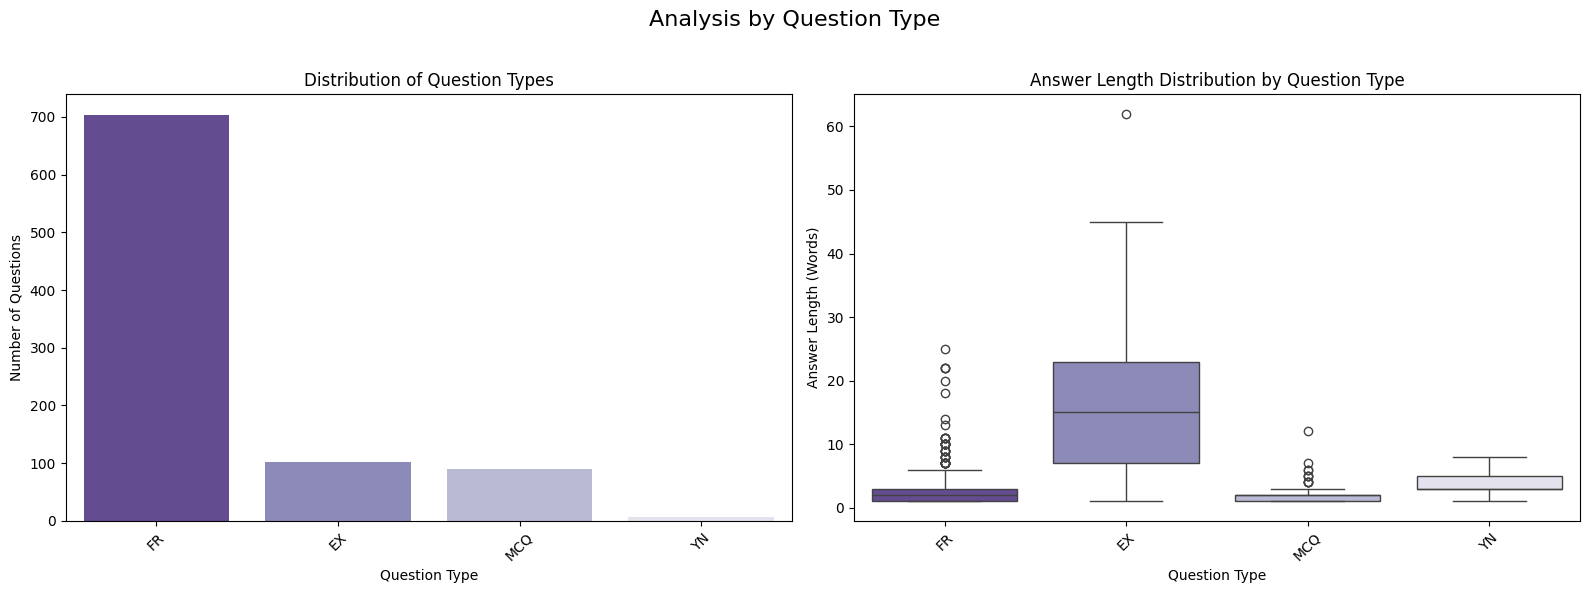


---

In [49]:
# Run the data ingestion pipeline to add questions from the new_questions_df to the data_for_analysis
status, payload = eda.run_data_ingestion_pipeline(new_questions_input=new_questions_df, 
                                                  main_dataframe=processed_df_for_analysis, 
                                                  vectorizer=vectorizer_global,
                                                  tokenizer=tokenize_text, 
                                                  critical_threshold=0.90, 
                                                  caution_threshold=0.70)

There are some interesting insights that can be made from the baseline status map, especially in comparison to the status dashboard before the new questiosn were added:

1. **Dataset curation**: The pipeline expanded the dataset to 902 high-quality, unique questions. These questions were refined from an initial raw count of 1279 questions.

2. **Improved question diversity**: The new questions have improved the diversity of question types. The number of Multiple-Choice Questions (MCQ) increased substantially from 3 to 89, and Explanatory (EX) questions grew five-fold from 20 to 102. The Yes/No and True-or-False (YN from 6 to 7) remain negligible. 

3. **Answer characteristics and uniqueness**: Approximately 5% of all answers (49 total) are non-text (numeric, date, or year). The analysis shows that Factual Recall (FR) questions have some repeated answers (44 of the 704 questions), while other types like EX and MCQ are almost entirely unique. The top answer keywords are informative and generally are about harry potter. For YN they are Yes and No as expected with the exception of "run". It indicates that at least one YN answer is not just the word a keyword (e.g. Yes, No, True) but a longer phrase that includes "run".

4. **Answer length distribution**: The visualizations clearly distinguish the question types by answer length. FR, MCQ, and YN answers are consistently short (2-3 words median), with the FR category showing many outliers with longer answers. In contrast, EX questions are much more verbose, with a high median length (15 words) and a wide distribution, indicating significant linguistic variety. The box plot visually confirms the findings. The large box and long whiskers for the EX category visually confirm its high variance. This means the answers are not only long on average but also vary greatly in length, which justifies the need for a sophisticated, semantic answer checker. The FR plot shows a very compressed box near the bottom with many outliers (the dots). This is a classic pattern indicating that most FR answers are consistently very short, but there are a few exceptions that are much longer. The same is true for MCQs, but here it will be in direct proportion to the question length since the answer would be one of the options presented.

5. **Classifier performance**: The keyword classification system proved to be effective. The *Unassigned Keyword Count* is zero for all categories, and interrogative keywords like "what" and "how" are correctly distributed across multiple question types, demonstrating the classifier's nuanced understanding of sentence structure. *"What"* appears predominently in FR but is also seen in EX and MCQ, *"which"* is in FR and also MCQ, and as expected "how" is FR (these are the quantitative types) and in EX (asking for reasoning). 

6. **Implications for answer checking**: These results make a strong case for using a hybrid answer-checking strategy. The short and consistent answer lengths for FR, MCQ, and YN questions mean they can be handled reliably with direct matching or simple fuzzy string logic. In contrast, the longer and more varied EX answers highlight the need for a more robust semantic similarity model to fairly evaluate player responses.

The pipeline log gave a warning for a potential duplicate, we can use the custom method to display the results to review it.

In [50]:
# Display the pipeline results using the custom helper from eda_scripts
eda.display_pipeline_results(status, payload)


PIPELINE EXECUTION FINISHED WITH STATUS: SUCCESS


### Pipeline Successful!

The main dataset has been updated. New total questions: 902


#### The following questions were added but are recommended for manual review:

,question,answer,is_numeric_answer,question_type,force_add_as_duplicate,question tokens,answer tokens,combined_unique_tokens,question_length,answer_length,interrogative_keywords,main_keyword,max_similarity_score_TEMP,existing_q_pos_max_score_TEMP,is_duplicate,needs_manual_review_TEMP,existing_original_question_id
4,According to the Ministry of Magic's classific...,Non-being,False,FR,False,"[accord, ministry, magic, classification, syst...","[non, be]","[accord, ministry, magic, classification, syst...",16,2,"[what, be]",what,0.707245,270,False,True,450


The report shows that the question *"According to the Ministry of Magic's classification system, what type of entity is a Boggart?"* is a potential duplicate to an existing question with an `original_quesition_id` of 450, with a similarity score of 0.71. We can review the existing question and if it is the same, we can drop the new question and then rerun the pipeline. If they are different, no action is required.

In [51]:
# Review the existing question with id 450
processed_df_for_analysis[processed_df_for_analysis['original_question_id']==450]

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword,question_length,answer_length,question_type,is_numeric_answer,answer_type
270,450,What is the Ministry of Magic classification s...,A creature's danger level,"[what, be, ministry, magic, classification, sy...","[creature, danger, level]","[what, be, ministry, magic, classification, sy...","[what, be]",what,8,5,FR,False,text


While question 450 (*"What is the Ministry of Magic classification system?"*) and the flagged new question have many phrases in common, they are fundamentally asking different things. So we can keep both questions and no manual intervention is requied.

Now let's retrieve the baseline dataset from the pipeline payload. Then we can take a look at how the answer classifier performed. 

In [52]:
baseline_trivia_df = payload.get('updated_trivia_dataset', pd.DataFrame())
baseline_trivia_df.reset_index(drop=True, inplace=True)
print(f"Shape of the baseline dataset: {baseline_trivia_df.shape}\n")
print("Baseline dataset info:\n")
baseline_trivia_df.info()
print(f"Baseline dataset sample:")
display(baseline_trivia_df.sample(5, random_state=16))

Shape of the baseline dataset: (902, 13)

Baseline dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   original_question_id    902 non-null    int64   
 1   question                902 non-null    object  
 2   answer                  902 non-null    object  
 3   question tokens         902 non-null    object  
 4   answer tokens           902 non-null    object  
 5   combined_unique_tokens  902 non-null    object  
 6   interrogative_keywords  902 non-null    object  
 7   main_keyword            902 non-null    object  
 8   question_length         902 non-null    int64   
 9   answer_length           902 non-null    int64   
 10  question_type           902 non-null    category
 11  is_numeric_answer       902 non-null    bool    
 12  answer_type             902 non-null    category
dtypes: bool(1), ca

,original_question_id,question,answer,question tokens,answer tokens,combined_unique_tokens,interrogative_keywords,main_keyword,question_length,answer_length,question_type,is_numeric_answer,answer_type
265,443,What is Hermione's cat's name?,Crookshanks,"[what, be, hermione, cat, name]",[crookshanks],"[what, be, hermione, cat, name, crookshanks]","[what, be, name]",what,7,1,FR,False,text
252,426,What does it mean when a magical creature is c...,Boring,"[what, do, mean, when, magical, creature, be, ...",[boring],"[what, do, mean, when, magical, creature, be, ...","[what, do, when, be]",what,17,1,FR,False,text
719,1245,What career does Harry Potter pursue after lea...,He works as an Auror for the Ministry of Magic.,"[what, career, do, harry, potter, pursue, leav...","[work, auror, ministry, magic]","[what, career, do, harry, potter, pursue, leav...","[what, do]",what,9,10,FR,False,text
712,1238,The Alihotsy is a magical tree noted for its d...,They cause hysteria (or uncontrollable laughte...,"[alihotsy, be, magical, tree, note, distinctiv...","[cause, hysteria, uncontrollable, laughter, hi...","[alihotsy, be, magical, tree, note, distinctiv...","[be, what, do, have, who]",what,27,7,EX,False,text
436,790,Who was the Journalist at The Daily Prophet in...,Rita Skeeter,"[who, be, journalist, daily, prophet, harry, p...","[rita, skeeter]","[who, be, journalist, daily, prophet, harry, p...","[who, be]",who,13,2,FR,False,text


The columns are all there, there are no nulls, and each column is the correct type. The `is_numeric` column is redundant now that we have added the more informative `answer_type` feature. Let's review the results and compare the columns. We can then delete the `is_numeric` column and update the pipeline accordingly.

Previously, dates and year were considered as non-numeric answers (i.e. `is_numeric==False`).  We can now compare how they are handled now by the `answer_type` column.

In [53]:
# Let's look at the how dates and years answers are classified in the baseline dataset
condition = (baseline_trivia_df['is_numeric_answer']==False) | (baseline_trivia_df['answer_type']!='text')
non_text_ans = baseline_trivia_df.loc[condition, ['original_question_id','question','answer','is_numeric_answer','answer_type']].sort_values(by='answer_type')
# Let's look at the date answers
non_text_ans[non_text_ans['answer_type']=='date']

,original_question_id,question,answer,is_numeric_answer,answer_type
520,978,When is Harry's birthday?,"July 31, 1980.",False,date
766,1292,What is Lily Potter's birthday?,"January 30, 1960",False,date
718,1244,On what chilling date did baby Harry Potter mi...,"Halloween (or October 31st), 1981",False,date
772,1298,What day did James and Lily Potter die?,October 31,False,date
752,1278,What is Snape's birthday?,"January 9, 1960",False,date
165,275,When is Neville's birthday?,July 30,False,date
495,921,On what date did the Battle of Hogwarts end wi...,"May 2, 1998",False,date
716,1242,"In Harry Potter and the Chamber of Secrets, on...",July 31 (Harry's birthday).,False,date


The `answer_type` method is correctly identifying dates even when they are tricky, non-standard formats such as in Q.1244 *"Halloween (or October 31st), 1981"*. These were all tagged as non-numeric. We are able to now correctly able to distinguish dates as another answer type. We can also look at the `year` data types.

In [54]:
# We can also look at the year answers
non_text_ans[non_text_ans['answer_type']=='year']

,original_question_id,question,answer,is_numeric_answer,answer_type
105,152,When did the wildcat gargoyle strike the place?,1911,False,year
717,1243,When was Ollivanders founded?,382 BC,True,year
745,1271,When was the Werewolf Code of Conduct developed?,1637,True,year
674,1200,When was the Golden Snidget first introduced i...,1269,True,year
412,736,When was Quidditch invented?,1050 AD,False,year
671,1197,When did Gringotts Wizarding Bank open?,1474,True,year
668,1194,When was Azkaban Prison established?,1718,True,year
1,1,When was Hogwarts founded?,10th century,False,year
783,1309,When was the first full description of the gam...,1398,True,year


The `answer_type` column has correctly labelled answers as years eventhough when presented in different formats such as *"10th century", "1050 AD", and "382 BC"*. The `is_numeric` column tags are inconsistent here since it was an input column for new questions in `v0` so introduced human error. The `answer_type` classifier correctly identifies this as an additional data type while reducing possibilities of error.

We can also identify any numeric answers that were missed by the `is_numeric` column.

In [55]:
# we can also look at any numeric answers that were missed by the v0 tagging
condition = (baseline_trivia_df['is_numeric_answer']==False) & (baseline_trivia_df['answer_type']=='numeric')
filter_missed_numeric = baseline_trivia_df.loc[condition, ['original_question_id','question','answer','is_numeric_answer','answer_type']]
print(f"There are {filter_missed_numeric.shape[0]} question(s) with numeric answers that were missed by the v0 tagging.")
filter_missed_numeric

There are 1 question(s) with numeric answers that were missed by the v0 tagging.


,original_question_id,question,answer,is_numeric_answer,answer_type
396,707,Quidditch players are constantly at risk of in...,700.,False,numeric


One numeric answer was tagged incorrectly as `False` in the `is_numeric` column but is correctly tagged in `answer_type`. We can also check vice-versa if there are any questions tagged as numeric by `is_numeric` but missed by `answer_type`.

In [56]:
condition = (baseline_trivia_df['is_numeric_answer']==True) & (baseline_trivia_df['answer_type']=='text')
filter_missed_answer_type = baseline_trivia_df.loc[condition, ['original_question_id','question','answer','is_numeric_answer','answer_type']]
print(f"There are {filter_missed_answer_type.shape[0]} question(s) with were not captured by the answer_type classification.")
filter_missed_answer_type

There are 7 question(s) with were not captured by the answer_type classification.


,original_question_id,question,answer,is_numeric_answer,answer_type
581,1107,How many Horcruxes have been destroyed at the ...,2 (Tom Riddle's diary and Marvolo Gaunt's ring),True,text
590,1116,How long should a Polyjuice Potion stew before...,1 Month,True,text
720,1246,Harry is known for his talents in Quidditch. W...,150 mph.,True,text
764,1290,How much gold do the Weasleys win in the Daily...,700 galleons,True,text
791,1317,How long did the longest Quidditch game last?,6 months,True,text
793,1319,What did the Dursleys give Harry for Christmas...,50 Pence,True,text
848,1374,How old was dumbledore when he died?,115 years old,True,text


The table above highlights a specific and intentional design choice. Answers that contain a numeric value but are paired with unit of measure (e.g., 6 months, 700 galleons) or additional explanatory text are correctly flagged with `is_numeric_answer` is `True` but are now classified as answer_type as `text`. This was done so that when checking answers the checker system will be signaled to perform a more complex validation. For instance, it allows the system to distinguish between a correct answer like *"700 galleons"* and an incorrect one like *"700 sickles"*, preserving the full context of the answer rather than just its numeric component.

Finally, to close out the review, we can look at a sample of where both `is_numeric` and `answer_type` both indicate the answer is `text`.

In [57]:
# filter where either is_numeric is False or answer_type is text
condition = (baseline_trivia_df['is_numeric_answer']==False) & (baseline_trivia_df['answer_type']=='text')
text_ans = baseline_trivia_df.loc[condition, ['original_question_id','question','answer','is_numeric_answer','answer_type']].sort_values(by='answer_type')
text_ans.sample(10)

,original_question_id,question,answer,is_numeric_answer,answer_type
433,781,Who killed Sirius Black?,Bellatrix Lestrange,False,text
225,381,Where would you look to find a bezoar?,In the stomach of a goat,False,text
569,1095,Which of the following spells is not used in T...,Confundo,False,text
557,1083,Who is the founder of the Slytherin house?,Salazar Slytherin,False,text
424,758,Which clause in the Code of Wand Use prohibits...,Clause Three,False,text
891,1417,Which dessert is known as Harry Potter’s favor...,Treacle Tart,False,text
542,1038,Where is the Hufflepuff common room?,By the kitchens,False,text
263,441,What effect does diluted Swooping Evil venom h...,Erases bad memories,False,text
347,601,Before the start of his second year at Hogwart...,With a flying car,False,text
21,28,"""Lemon Drop"" is the password to whose office?",Dumbledore,False,text


The `answer_type` column is working well, we can drop the `is_numeric` column and update the pipeline accordingly.

In [58]:
baseline_trivia_df = baseline_trivia_df.drop(columns='is_numeric_answer')
baseline_trivia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   original_question_id    902 non-null    int64   
 1   question                902 non-null    object  
 2   answer                  902 non-null    object  
 3   question tokens         902 non-null    object  
 4   answer tokens           902 non-null    object  
 5   combined_unique_tokens  902 non-null    object  
 6   interrogative_keywords  902 non-null    object  
 7   main_keyword            902 non-null    object  
 8   question_length         902 non-null    int64   
 9   answer_length           902 non-null    int64   
 10  question_type           902 non-null    category
 11  answer_type             902 non-null    category
dtypes: category(2), int64(3), object(7)
memory usage: 72.8+ KB


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 8.2: Data schema (data dictionary)
Now that we have a baseline dataset, we can formally define the associated data dictionary.

| Column Name | Data type |Description |
|--------------------|-----------|---------------------------------------------------------------------------------------------------------|
|`original_question_id`|int64|A unique, sequential ID assigned automatically by the pipeline|
|`question`|object(str)| The trivia question text |
|`answer`|object(str)| The answer to the associated trivia question|
|`question tokens`|object (NumPy ndarray of strings)| A list of cleaned and lemmatized tokens from the question text|
|`answer tokens`|object (NumPy ndarray of strings)| A list of cleaned and lemmatized tokens from the answer text|
|`combined_unique_tokens`|object (NumPy ndarray of strings)| A combined array of tokens from the question and answer|
|`interrogative_keywords`|object (NumPy ndarray of strings)| An array of all the idenitified interrogative keywords present in the question|
|`main_keyword`|object(str)| The defining interrogative keyword, e.g. "what"|
|`question_length`|int64| The number of words in the question|
|`answer_length`|int64| cThe number of words in the answer|
|`question_type`|category| Classification of the question as: `FR`, `EX`, `MCQ`, `YN`, or `Other`| 
|`answer_type`|category| Classification of the answer as: `text`, `numeric`, `date`, and `year`| 

# 9: Data quality assurance and finalization

## 9.1: Quality Assurance (QA) scheme
To ensure the long-term quality and consistency of the trivia dataset, the following multi-stage Quality Assurance (QA) scheme will be implemented.

### 9.1.1: Current quality confirmation (immediate implementation)
We can use statistical methods on existing features to flag potential issues for manual review.

- **Readability analysis**: Calculate a readability score (Flesch-Kincaid) for each question. Flag questions with unusually high or low scores to identify those that may be awkwardly phrased or overly complex. While this is a reasonable first-pass assessment, it has known limitations. The formulae rely on superficial features (e.g., sentence length and syllable counts) and may not always reflect the true complexity of a question with specialized Harry potter terms (typically long and latin based, e.g. transfiguration or wingardium leviosa).

- **Statistical outlier detection**: Analyze the distribution of question_length and answer_length. Flag questions in the extreme percentiles (e.g., top 1% and bottom 1%) as potential outliers that may be too verbose or lack context.

### 9.1.2: Automated quality assurance process
A more comprehensive, score-based system will be designed to flag issues with better precision. Once the methodologies and score schemes are defined, tested, and finalized, a QA pipeline can be used to automate the process. A compound scoring system could be used to create a weighted score based on defined individual quality attributes for each question. These attribute would include:

1. **Technical quality score**: will measure how well a question is phrased. It will used semantic embeddings to create a numerical score to measure how structurally and linguistically similar to auxilliary question in its question type class. Outliers can then be highlighted. A sentence-BERT model will be trained for answer checking and will create embedding vectors. Individual vectors can be compared to the average vector (centroid) for each question type. Using this, we can calculate an outlier score by measuring the distance of the question's vector from the centroid. A high-score (large distance) would indicate potential outliers that can be flagged for review.

2. **Contextual relevance score**: will be a measure of lore content. This will consider the question source, for example placing higher value on questions directly from the main seven books compared to auxilliary sources such as *Quidditch through the Ages*. This could also be supplemented with other features such as question type (e.g EX slight more than FR), and NER labels or classes.

3. **Entity validation score**: can be used to confirm that known Harry Potter specific terms are included in the questions and answers. It would be generated by cross-referencing the entities (characters, locations, spells) found in the question and answer against curated lists (gazetteers that will be used for NER classification) of known lore.

4. **Semantic consistency score**: Although not foolproof, this can be a proxy for checking factual accuracy to flag outliers. This will be calculated as the cosine similarity score between a question and its answer. A low score would show they are dissimilar. For example, if the question was "Who was the headmaster of hogwarts when Harry joined in first year?", answer could be ranked by the score: "Albus Dumbledore" would be very high, "Hermione Granger" would be lower because the relationship is incorrect, and "Donald Trump" would be very low (a nonsensical answer).

The compounded overall quality score, based on weighted scores of the individual attributes, would need to directly correlate to quality (ie. high score, high quality inidication) and be intuitive (e.g. normalized score out of 10 or a percentage). We would then be able to rank questions and flag questions beyond a defined thresholds for manual review. These scores will need to be defined, assessed, calibrated, and tested. They can be incorporated into an automated QA pipeline. For new questions, the QA pipeline will be used as a pre-processing step before the data ingestion pipeline:

1. **Automated scoring**: The four metric scores and overall quality scores will be automatically calculated and added as features to the new questions data frame.

2. **Targeted flagging for manual review**: Questions will be flagged for manual review based on threshold criteria developed for each quality attribute scores and the overall score, creating a small and targeted list of the likely problematic questions. This will be a manual review checkpoint along with spot checking of a proportional sample of the dataset (e.g  5~10% of the new questions). Only once the whole batch is approved through checking can the questions be appended to the main dataset using the data ingestion pipeline.

3. **Iterative improvement**: The insights gathered from reviewing the flagged questions will provide a feedback loop, informing future prompt engineering for the LLM, updates to the NER gazetteers, and refinements to the scoring models themselves.

The baseline dataset will need a one-time update to add all the qualit score features. The new workflow for ingesting new questions will then need to be updated. The current data ingestion pipeline will need to be refactored into two components, with the quality assurance pipeline first, followed by a simplified data ingestion pipeline :

1. **QA pipeline**: This new pipeline will handle all feature engineering for incoming data. It will generate tokens, calculate lengths, classify question and answer types, any new NLP featues, and produce the four quality scores. Its output will be an enriched dataframe with a report of flagged items for manual review.

2. **Ingestion pipeline**: This pipeline will be simplified to focus only on its core task. It will take the final, checked and approved set of new questions from the QA process and safely integrating it into the baseline dataset. Its responsibilities will be the final duplicate check, ID assignment, and concatenation.

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

## 9.2: Current quality confirmation
Based on the existing features, we can start by assesing the readability level of the baseline dataset

### 9.2.1: Readability analysis

Traditional readability indexes can give an quick indication to the linguistic complexity of a question. While they are not a perfect measure, they are useful for spotting statistical outliers—questions that might be too simple or complex—and for assessing the overall difficulty of the dataset. The reading level of the actual books also gives a real-world benchmark to compare the results against: 

|Book | [US grade levels](https://advancebookreaders.com/harry-potter-reading-level-age-and-grade/) | [Flesh-Kincaid Grade Level (FKGL)](https://worthybookss.com/what-is-the-reading-level-for-harry-potter/#Harry%20Potter%20Reading%20Levels%20Chart)|
|-|-|-|
|Books 1-2| Grades 4 to 5| [5.5, 6.7]|
|Books 3-4| Grades 5 to 6| [5.8, 6.8]|
|Books 5-7| Grades 7 to 8| [7.2, 7.4, 7.7]

The main metrics considered for comparison of the dataset are Flesch Reading Ease (FRE),  Flesch-Kincaid Grade Level (FKGL), Gunning Fog Index (GFI), and the SMOG Index. The table below gives a brief comparison of the four indices: 

| Metric | What It Measures | Output Scale | Strengths | Limitations |
| :--- | :--- | :--- | :--- | :--- |
| **Flesch Reading Ease (FLE)** | Average sentence length & syllables per word. | 0–100<br>(Higher is easier) | - Widely used standard.<br>- Provides a broad range of scores for comparison. | - Score is not directly intuitive.<br>- Requires mapping to a grade level. |
| **Flesch-Kincaid Grade Level (FKGL)** | Average sentence length & syllables per word. | U.S. school grade level<br>(e.g., 8.0 = 8th grade) | - Highly intuitive and easy to explain.<br>- Directly correlates to an educational benchmark. | - Can produce negative scores for very simple text.<br>- Sensitive to long but common domain-specific words. |
| **Gunning Fog Index (GFI)** | Sentence length & percentage of "complex" words (3+ syllables). | Grade-level estimate<br>(Higher is more complex) | - Good at identifying text with dense, technical vocabulary. | - Tends to overestimate the difficulty of texts with many proper nouns (like in the HP universe). |
| **SMOG Index** | The number of polysyllabic words (3+ syllables). | Grade-level estimate<br>(Validated on larger texts) | - Simple formula, provides a consistent and reliable score. | - Can be less granular for very short texts.<br>- Its reliance on a fixed word count can be challenging for single sentences. |

However, it is also important to recognize the limitations of these indicies. These scores are derived from superficial features like sentence length and syllable counts [[2]](#11-references) and can struggle with the domain-specific vocabulary [[3]](#11-references) of the Harry Potter universe. Despite these drawbacks, they can provide a useful, quick, high-level heuristic for quality assurance.

We can compare the indices results with the baseline dataset.

In [59]:
# create a working copy of the main df
readability_checks_df = baseline_trivia_df[['original_question_id','question', 'answer','question_type']].copy()
# check: Flesch-Kincaid Grade Level (lower = simpler)
readability_checks_df['flesch_reading_ease'] = readability_checks_df['question'].apply(textstat.flesch_reading_ease).round(2)  # type: ignore
readability_checks_df['flesch_kincaid_grade'] = readability_checks_df['question'].apply(textstat.flesch_kincaid_grade).round(2)  # type: ignore
readability_checks_df['gunning__fog_index'] = readability_checks_df['question'].apply(textstat.gunning_fog).round(2)  # type: ignore
readability_checks_df['smog_index'] = readability_checks_df['question'].apply(textstat.smog_index).round(2)  # type: ignore
# display head of df
readability_checks_df.sample(5, random_state=16)

,original_question_id,question,answer,question_type,flesch_reading_ease,flesch_kincaid_grade,gunning__fog_index,smog_index
265,443,What is Hermione's cat's name?,Crookshanks,FR,117.16,-1.84,2.00,3.13
252,426,What does it mean when a magical creature is c...,Boring,FR,65.17,8.39,13.86,13.02
719,1245,What career does Harry Potter pursue after lea...,He works as an Auror for the Ministry of Magic.,FR,47.30,8.90,3.60,3.13
712,1238,The Alihotsy is a magical tree noted for its d...,They cause hysteria (or uncontrollable laughte...,EX,39.60,11.09,15.77,14.55
436,790,Who was the Journalist at The Daily Prophet in...,Rita Skeeter,FR,63.49,7.63,8.28,8.84


Looking at the dataset sample scores, each index has unique sensitivities to different aspects of text complexity:
- The FKE score is relativly more difficult to interpret compared to the other indicies.
- The FKGL provides a balanced, baseline assessment. It is directly interpretable. It also delivers a reasonable score for complex, lore-heavy questions (e.g., Q.1238) but can produce negative scores for very short, simple questions (e.g., Q.443).
- The GFI and SMOG Index, in contrast, are sensitive to multi-syllable words. They assign higher scores to questions rich with domain-specific vocabulary (like Q.426) which can sometimes overestimate the actual difficulty for a player. Conversely, they can also assign very low scores to questions that are long but use simple vocabulary (e.g., Q.1245).

In [60]:
readability_checks_df[['flesch_reading_ease','flesch_kincaid_grade','gunning__fog_index','smog_index']].describe().round(2)

,flesch_reading_ease,flesch_kincaid_grade,gunning__fog_index,smog_index
count,902.00,902.00,902.00,902.00
mean,64.41,7.33,9.57,8.97
std,23.24,4.24,5.17,4.23
min,-18.20,-2.23,1.20,3.13
25%,49.49,4.00,4.85,3.13
50%,66.10,6.84,9.07,8.84
75%,81.86,10.11,13.17,11.21
max,118.18,22.71,27.32,22.92


Looking at the descriptive statistices of the indicies:

- **Reference statisitics from the main books**: As highlighted earlier in the section, the FKGL for the Harry Potter book series ranges from 5.5 to 7.7, with a mean grade of 6.7 and can be used a benchmark for comparison of the indices.

- **Comparison of readability indices**: Overall, all grade-level metrics are strongly correlated. However, the Flesch Reading Ease score, with its 0-100 scale, is less intuitive than a direct grade equivalent. Among the grade-level scores, the FKGL aligns best with the source material, with a mean of 7.33 that is very close to the books' average. In contrast, the Gunning Fog and SMOG indices are more sensitive to the domain-specific vocabulary, resulting in higher average scores. Therefore, FKGL will serve as the primary baseline, with GFI used as a secondary check to flag questions with unusually high lexical complexity.

- **Average readability of the dataset**: The dataset's average readability is quite accessible for the intended players with a mean (7.33) and median (6.84) corresponding to a middle school reading level. The mean being slightly higher than the median indicates a right skew caused by a tail of more complex questions.

- **Wide range of complexity** TThe dataset contains a high degree of variety, confirmed by a large standard deviation (4.24) and a wide range between the minimum (-2.23) and maximum (22.71) scores. This reflects a healthy mix of very simple and linguistically complex questions. The negative minimum score is unusual but it indicates a very simple question as we saw in the sampling (similar to Q.443 *"What is Hermione's cat's name?"*).

We need to define a cut-off threshold levels for both too simplistic and complex questions that should be flagged for review. Looking at the too complex questions, we can evaluate the 90, 95 and 98 percentiles as cutoffs:

In [61]:
# Calculate the scores for different percentile cutoffs
percentiles = [0.90, 0.95, 0.98, 0.99]
for p in percentiles:
    cutoff = readability_checks_df['flesch_kincaid_grade'].quantile(p)
    count = (readability_checks_df['flesch_kincaid_grade'] > cutoff).sum()
    print(f"{int(p*100)}th percentile (top {int((1-p)*100)}%): Grade > {cutoff:.2f} ({count} questions)")

90th percentile (top 9%): Grade > 13.04 (91 questions)
95th percentile (top 5%): Grade > 14.93 (45 questions)
98th percentile (top 2%): Grade > 17.24 (19 questions)
99th percentile (top 1%): Grade > 18.70 (10 questions)


The 99th percentile results in 10 questions for review which seems as a reasonable cutoff. We can also look at sample questions to verify the difference between a cutoff of 90th and 99th percentile and confirm that the 99 percentiles should be the cutoff.

In [62]:
# Sample FKGL eadability scores in the 90th percentile 
fkgl_90th_percentile = readability_checks_df['flesch_kincaid_grade'].quantile(0.90)
outlier_readability_questions = readability_checks_df[readability_checks_df['flesch_kincaid_grade'] >= fkgl_90th_percentile]
print(f"Number of questions with outlier readability scores: {outlier_readability_questions.shape[0]}")
outlier_readability_questions.sample(5, random_state=16)

Number of questions with outlier readability scores: 91


,original_question_id,question,answer,question_type,flesch_reading_ease,flesch_kincaid_grade,gunning__fog_index,smog_index
574,1100,Bouncing Bulbs are notoriously difficult for w...,Potting,MCQ,10.82,15.73,18.90,15.90
740,1266,Which rarely offered elective at Hogwarts is r...,Alchemy,FR,28.05,13.07,14.00,13.02
672,1198,The three D's of Apparition do not include whi...,Dimension,MCQ,5.53,16.46,18.90,17.12
849,1375,In Harry Potter and the Half-Blood Prince and ...,Harry believed the Ministry was failing (or ac...,EX,30.33,13.25,15.04,13.82
808,1334,"During their grand, defiant exit from Hogwarts...",A Portable Swamp,FR,33.46,16.29,20.14,17.12


The 90th percentile questions have high readability scores but the complexity can be considered appropriate for the target audience and the trivia format. The high scores are mainly caused by two factors: 
1. the use of domain-specific vocabulary (e.g., "Herbology," "Apparition"), which would be familiar to Harry Potter fans, and
2. the inherent structure of Multiple-Choice Questions, which are longer because of their list of options at the end.
We can also see that the GFI is consistently higher than FKGL because it weighs polysyllabic words more, for example in Q.1100 (*Bouncing Bulbs are notoriously difficult for which of these Herbology actions: Watering, Pruning, Potting, or Fertilizing?*), the GFI is 18.9 while the FKGL is 15.7 althrough the question is relatively straight forward.

Overall, these questions are considered acceptable for the game. Flagging over 90 such questions for review would be inefficient especially since they are not inherently flawed. A more strict cutoff, such as the 98th or 99th percentile, will be more effective for isolating only the most extreme and any problematic outliers for a targeted quality check. 

We can look at the 99th percentile results to confirm:

In [63]:
# FKGL eadability scores in the 99th percentile 
fkgl_99th_percentile = readability_checks_df['flesch_kincaid_grade'].quantile(0.99)
outlier_readability_questions = readability_checks_df[readability_checks_df['flesch_kincaid_grade'] >= fkgl_99th_percentile]
print(f"Number of questions with outlier readability scores: {outlier_readability_questions.shape[0]}")
outlier_readability_questions

Number of questions with outlier readability scores: 10


,original_question_id,question,answer,question_type,flesch_reading_ease,flesch_kincaid_grade,gunning__fog_index,smog_index
639,1165,In which of these scenarios would you use the ...,Whispering in the library without being overheard,MCQ,19.03,19.30,24.29,21.19
670,1196,Which of the following is NOT a plausible side...,Insatiable Hunger,MCQ,5.49,18.70,21.20,19.29
687,1213,Why was Sir Nicholas de Mimsy-Porpington (Near...,His head wasn't completely severed,MCQ,17.55,19.76,23.29,19.29
709,1235,"According to wizarding history, what was the n...",Lady Grieve,FR,11.12,18.91,22.63,20.27
714,1240,The Ministry of Magic's comprehensive classifi...,Newt Scamander,FR,-3.60,22.71,23.29,20.27
743,1269,"In Harry Potter and the Order of the Phoenix,...",Flagrate,FR,19.03,19.30,23.14,19.29
769,1295,During the Second Task of the Triwizard Tourna...,Merpeople,FR,1.48,19.51,27.32,22.08
773,1299,"In Harry Potter and the Deathly Hallows, what...",Dittany,FR,21.45,18.96,19.71,17.12
810,1336,Despite their lack of exciting magical abiliti...,Their mucus (or slime).,FR,3.17,19.77,26.91,22.92
835,1361,When did Lily Evans first meet Severus Snape: ...,"As children, in a park near their homes before...",MCQ,40.03,19.60,21.70,13.02


Again here the GFI is more sensitive to specialized vocabulary than FKGL. For example, Q.1295, the phrase "Triwizard Tournament" gives GFI sccore of 27.3, much higher than the FKGL of 19.5. This pattern is repeated in other questions with Harry Potter specific terms like "Magizoologist" and "Mimsy-Porpington."
We can also see that these high scores dont mean the questions are poorly written, but instead they test deep and specific lore using terminology from the books. So, the 99th percentile seems to be a reasonable cutoff and and effective way to isolate a small, manageable list of questions for a final quality check. The goal of this review is not to eliminate them, but simply to confirm that the complexity is necessary and the phrasing is as clear as possible. This process provides a strong final quality gate for the dataset.

We can repeat the review for the lowest percentile:

In [64]:
# FKGL eadability scores in the 1 percentile 
fkgl_1rst_percentile = readability_checks_df['flesch_kincaid_grade'].quantile(0.01)
outlier_readability_questions = readability_checks_df[readability_checks_df['flesch_kincaid_grade'] <= fkgl_1rst_percentile]
print(f"Number of questions with outlier readability scores: {outlier_readability_questions.shape[0]}")
outlier_readability_questions

Number of questions with outlier readability scores: 11


,original_question_id,question,answer,question_type,flesch_reading_ease,flesch_kincaid_grade,gunning__fog_index,smog_index
124,191,What's Tonks dad's name?,Ted,FR,118.18,-2.23,1.6,3.13
176,295,When do Puffskeins hum?,When they're content.,FR,118.18,-2.23,1.6,3.13
218,366,Where are the vaults kept in Gringotts Bank?,Deep underground.,FR,114.12,-0.67,3.2,3.13
240,406,What does the Drought Charm cause?,Dryness,FR,116.15,-1.45,2.4,3.13
256,430,What is the Grim?,A spectral dog,FR,118.18,-2.23,1.6,3.13
265,443,What is Hermione's cat's name?,Crookshanks,FR,117.16,-1.84,2.0,3.13
345,597,What are the two pubs in Hogsmeade called?,The Three Broomsticks and The Hog's Head.,FR,114.12,-0.67,3.2,3.13
348,602,Where does the Sopophorous Plant grow?,Gloomy marshlands.,FR,116.15,-1.45,2.4,3.13
431,779,The Pack Charm is what type of charm?,Household Charm,FR,114.12,-0.67,3.2,3.13
442,799,What is the name of Filch's cat?,Mrs. Norris,FR,115.13,-1.06,2.8,3.13


These questions have the lowest readability scores (the bottom 1%), not because of errors but are good trivia questions. The low scores are a direct result of their simple, concise phrasing with accessible language. The questions are effective because the simplicity of the structure doesn't take away the challenge of the answer. For example, Q.597 (*"What are the two pubs in Hogsmeade called?"*) is very easy to understand but recalling the names might not be easy for someone who hasn't read the books in a while, making it a perfect trivia question.

Therefore, these outliers are necessary and contribute to the dataset's variety and don't need to be removed or any quality-driven edits. For now this manual review of the is sufficient as a quality assurance step. In a future iteration, this process can be fully automated. The new method will use a two-step, hybrid approach: first, using the FKGL to flag general outliers, and second, using the GFI to specifically identify questions with high lexical density. This automated readability check will become one component of a full QA pipeline, which will leverage other NLP and machine learning techniques (refer to [section 9.1](#91-quality-assurance-scheme)) to flag a small, targeted subset of questions for final manual review.


### 9.2.2: Statistical length outliers

The readability score analysis was quite comprehensive and there is considerable overlap with a statistical length outlier analysis since the readability scores inherently account for sentence lengths. For the current scope, the readability analysis is considered sufficient. In future, an outlier analysis on the question and answer lengths could be implemented. This would provide an additional layer of quality assurance, specifically to catch questions that are exceptionally wordy but use simple vocabulary or ones that may be truncated (an issue present in the raw dataset). 

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 10: Summary and key findings
This phase of the project successfully transformed the raw trivia data into a clean, feature-rich, and validated baseline dataset. The process involved in-depth analysis, robust feature engineering, and the development of a scalable data ingestion pipeline.

- **Significant data curation via cosine similarity analysis**: An in-depth cosine similarity analysis was the cornerstone in supporting data curation. Around a 100 incomplete or incorrect questions were replaced with high-quality and diverse questions types. This helped balance the question types within the baseline dataset a bit more. The Question-Question (Q-Q) comparison was key in identifying and removing subtle near-duplicates that differed only by punctuation or differences in wording, and reduced the question count from 1084 to 902 high-quality records. The Question-Answer (Q-A) analysis confirmed expected linguistic patterns, such as high word overlap for Yes/No questions and low overlap for Factual Recall questions. Finally, the Answer-Answer (A-A) analysis validated the dataset's high topic diversity, confirming that 86% of answers are unique. The few repeated answers correspond to core Harry Potter concepts like characters, spells, and locations.

- **Robust feature engineering**: Another significant portio of work involved enriching the dataset with new features. A refined tokenizer, which now correctly lemmatizes text before removing stop words, provides a solid foundation for all NLP tasks. Building on this, rule-based classifiers were developed to assign a `question_type` and `answer_type` to each entry. These features enabled a deep analysis of the dataset's composition and a preliminary quality assurance check using readability scores and they will be critical for developing the game's hybrid answer-checking logic.

- **Standardized and scalable workflow**: A systematic *data ingestion pipeline* was developed to standardize the process of adding new content. The pipeline validates, checks for duplicates, and ingests new questions in a consistent manner. This is a far more robust approach than simple concatenation.  It was used to add corrected questions, which needed to be edited (e.g. incomplete MCQs) or replaced (incorrect, out-of-scope), back to the dataset in one batch. Complimenting the pipeline, an *automated status map dashboard* was created to provide a quick, comprehensive overview of the dataset's metrics and enable benchmarking and tracking the datasets evolution over time.

- **Final Baseline dataset**: The resulting dataset of 902 questions is now the official baseline for future development. Its key characteristics are:
    - *Improved diversity*: The question type distribution is now 78% Factual Recall (FR), 11% Explanatory (EX), 10% Multiple-Choice (MCQ), and 1% Yes/No (YN). This is a significant improvement, with the MCQ count increasing from 3 to 89 and the EX count growing five-fold from 20 to 102.
    - *Answer characteristics*: The vast majority of answers are textual (94%). The median answer lengths clearly distinguish the question types; FR, MCQ, and YN answers are consistently short (2-3 words), while EX questions are more verbose (15 words median), highlighting their linguistic richness.

## 10.1 : Gaps and limitations
While the current dataset is a strong foundation, the analysis also identified key areas for improvement:

1. **`question_type` automation**: The classifier currently requires `question_type` as a manual input for new questions because the rule-based logic cannot yet handle the nuance of all cases (e.g., distinguishing between factual and explanatory "what" questions).

2. **Dataset imbalance**: Despite improvements, the dataset remains heavily skewed towards factual recall questions. More explanatory questions are needed to provide richer data for the planned semantic analysis.

3. **Vectorizer drift**: The TF-IDF vectorizer was trained on the baseline vocabulary. As new, more verbose EX questions are added, its vocabulary will become outdated, reducing the accuracy of the duplicate detection system.

4. **Lack of contextual understanding**: The current analysis lacks a deep thematic understanding of the questions. Advanced NLP techniques like NER and embedding analysis are needed to uncover contextual coverage and potential biases.

5. **Superficial QA**: The readability analysis is a good first-pass quality check but it relies on superficial metrics (sentence length, number of syllables, etc). A more comprehensive QA scheme is required to fully assess the dataset's integrity.

## 10.2: Nexts steps
Building on these findings, further work will focus on strategically enhancing the dataset and the supporting methods.

### 10.2.1. Dataset expansion and balancing
The immediate goal is to generate an initial batch of ~500 new, high-quality questions, with a strong focus on Explanatory (EX) types to enrich the dataset for future semantic analysis. This will be accomplished by engineering a "Master Prompt" for a generative AI, designed to mitigate common LLM weaknesses observed when generating some of the replacement questions for the baseline dataset. The prompt will:

- **Factual accuracy**: ground all output in a provided source text and require citations to prevent factual "hallucinations."
- **Question quality**: enforce a strict format for MCQs and include instructions for conciseness to avoid overly verbose or leading questions.
- **Consistent tone**: leverage few-shot prompting, using high-quality examples from the baseline dataset to guide the model's output.
### 10.2.2. Pipeline and model enhancements
With a larger, more diverse dataset, the supporting models and pipelines will also need to be upgraded:

- **Automate `question_type` classification**: The classifier will be updated to handle "what" questions, and this logic will be fully integrated into the ingestion pipeline, removing `question_type` as a required input. Later, train a model (e.g., Random Forest) to predict the question_type ('FR', 'EX', 'YN', 'MCQ'). This will provide a more data-driven classification than the keyword-based rules.
- **Retrain Vectorizer**: To prevent model drift, the TF-IDF vectorizer will be retrained on the complete, expanded dataset, and a maintenance protocol will need to be established for future updates.
- **Improve near-duplicate detection**: The current system can be enhanced by exploring semantic models like Sentence-BERT to create a more powerful, automated system for finding near-duplicates.

### 10.2.3. Comprehensive quality assurance and advanced features
The QA scheme will be formalized and automated, and new, context-driven features will be developed:

- **Hybrid answer checker**: A comprehensive, nuanced answer-checking module will be built that uses the `question_type` and `answer_type` features to route responses to the appropriate logic (e.g., direct matching for numeric, semantic similarity for EX).

- **Contextual feature engineering**: In-depth NLP analysis will be performed to create new features like theme/topic tags, difficulty scores, custom NER classes, and embedding vectors.

- **Formalize QA**: Finalize the quality assurance scheme. Define and calculate the quality attributes to assess questions. After, testing refactor the data ingestion pipeline into two separate pipelines for quality assurance and data ingestion. 


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

# 11: References

1. [1] J. K. Rowling (Kennilworthy Whisp), *Quidditch Through the Ages*, Chapter 4: “The Arrival of the Golden Snitch,” 1st American ed., New York: Arthur A. Levine Books, 2001. Available: https://hp.subhamram.in/J.K.%20Rowling%20-%202001%20Quidditch%20Through%20the%20Ages.pdf 

2. S. Vajjala, “Trends, Limitations and Open Challenges in Automatic Readability Assessment Research,” in *Proc. Language Resources and Evaluation Conference (LREC)*, Marseille, France, Jun. 2022, pp. 5366–5377. Available: https://aclanthology.org/2022.lrec-1.574.pdf

3. C. Jarrett and J. “Ginny” Redish, “Readability Formulas: 7 Reasons to Avoid Them and What to Do Instead,” *UXmatters*, Jul. 29, 2019. [Online]. Available: https://www.uxmatters.com/mt/archives/2019/07/readability-formulas-7-reasons-to-avoid-them-and-what-to-do-instead.php


<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>

---

### Exports for further analysis

**1. Updated Trivia dataframe** saved as a parquet file to keep the data type information.

In [65]:
# 💾 Checkpoint: Notebook 2 output dataframe 

output_path = nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb2_output_v0.parquet"

if not output_path.exists():
    print(f"File not found. Saving data to {output_path}...")
    baseline_trivia_df.to_parquet(output_path)
else:
    print(f"File {output_path.name} already exists. Skipping save.")

File dataframe_nb2_output_v0.parquet already exists. Skipping save.


**2. Common vectorizer for subsequent notebooks**

In [ ]:
# Export tokenizer so it can be used by other notebooks.
save_path = nb_cfg.MODELS_DIR / "tfidf_vectorizer_v0.1.0.joblib"

# prevent overwriting existing vectorizer
if not save_path.exists():
    print(f"File not found. Saving vectorizer in {save_path}...")
    joblib.dump(vectorizer, save_path)
else:
    print(f"Vectorizer file '{save_path.name}' already exists. Skipping save.")

Vectorizer file 'tfidf_vectorizer_v1.0.0.joblib' already exists. Skipping save.


**3. Basline trivia dataset export for the CLI-MVP game**

In [ ]:
# 💾 Checkpoint: Baseline trivia dataset csv for the MVP v0

output_path = nb_cfg.FINAL_DATA_DIR / "trivia_dataset_v0.1.0_baseline.csv"

if not output_path.exists():
    print(f"File not found. Saving data to {output_path}...")
    baseline_trivia_df.to_csv(output_path)
else:
    print(f"File {output_path.name} already exists. Skipping save.")

File not found. Saving data to /Users/reemasipra/Documents/GitHub_Repos/Harry_Potter_Trivia/data/05_final/trivia_dataset_v1.0.0_baseline.csv...


---

<a href="#table-of-contents" style="display:inline-block; padding:8px 16px; background-color:#5e4b8b; color:white; text-align:center; text-decoration:none; border-radius:4px;">Back to TOC</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#1-introduction" style="display:inline-block; padding:8px 16px; background-color:#a390d4; color:white; text-align:center; text-decoration:none; border-radius:4px;">Return to the Top</a>

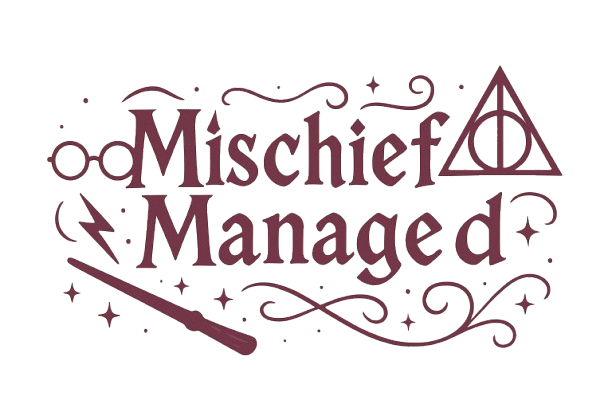